In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('libraries loaded')

libraries loaded


In [2]:
# Setup
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PALETTE = {
    'Logistic Regression': 'blue',
    'Random Forest': 'green',
    'SVM': 'red',
    'XGBoost': 'orange',
}

MARKET_COLORS = {
    'US': 'midnightblue',
    'India': 'darkorange',
    'UK': 'crimson',
}
print('setup done.')

setup done.


In [3]:
# Dataset Loading

FILE_PATHS = {
    'US':    r'../data/raw/Shark Tank US dataset.csv',
    'India': r'../data/raw/Shark Tank India.csv',
    'UK':    r'../data/raw/Dragons Den UK dataset.csv',
}

RANDOM_STATE = 42
CV_FOLDS     = 5
TEST_SIZE    = 0.20

In [4]:
import os
raw_datasets = {}
for market, path in FILE_PATHS.items():
    try:
        df = pd.read_csv(path, encoding='latin1')
        raw_datasets[market] = df
        print(f"{market} has  {df.shape[0]} rows x {df.shape[1]} cols")
    except FileNotFoundError:
        print(f"{market}  file not found: {path}")
    except Exception as e:
        print(f"{market}  error: {e}")

missing = [m for m in ['US','India','UK'] if m not in raw_datasets]
if missing:
    raise FileNotFoundError(
        f"Failed to load: {missing}\n"
        "Need to Update file paths above and re-run all cell."
    )
print("All 3 Datasets Loaded.")

US has  1485 rows x 53 cols
India has  789 rows x 80 cols
UK has  1473 rows x 56 cols
All 3 Datasets Loaded.


In [5]:

# Exploratory Data Analysis
# helper functions
def to_binary(val):
    if pd.isna(val): return np.nan
    s = str(val).lower().strip()
    if s in ('yes','true','1','y','deal made','deal successful',
             'received offer','deal','1.0'): return 1
    if s in ('no','false','0','n','no deal','0.0'): return 0
    try: return 1 if int(float(val)) > 0 else 0
    except: return np.nan

POSSIBLE_TARGETS = [
    'Got Deal','got deal',
    'Received Offer','received offer','Deal Made','deal made',
    'Deal Successful','deal successful','Deal','deal',
    'Investment Made','investment made','Funded','funded',
]

target_col_map = {}
for market, df in raw_datasets.items():
    for col in POSSIBLE_TARGETS:
        if col in df.columns:
            target_col_map[market] = col
            break

market_labels = {'US':'Shark Tank US','India':'Shark Tank India','UK':"Dragons' Den UK"}

print("target columns found:")
for k,v in target_col_map.items():
    print(f"{k} -> '{v}'"  )

target columns found:
US -> 'Got Deal'
India -> 'Received Offer'
UK -> 'Received Offer'


In [6]:
# need to inspect each dataset by shape, types, missing values
def inspect_dataset(df, name):
    print(f"\n{name}")
    print(f"shape    : {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"dtypes   : {dict(df.dtypes.value_counts())}")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print(f"missing  : {len(missing)} columns with nulls")
        for col, cnt in missing.head(15).items():
            pct = cnt / len(df) * 100
            print(f"{col:45s}  {cnt:5d}  ({pct:5.1f}%)")
    else:
        print(f"missing  : none")

for market, df in raw_datasets.items():
    inspect_dataset(df, market_labels[market])


Shark Tank US
shape    : 1485 rows x 53 columns
dtypes   : {dtype('float64'): np.int64(35), <StringDtype(storage='python', na_value=nan)>: np.int64(15), dtype('int64'): np.int64(3)}
missing  : 45 columns with nulls
Deal Has Conditions                             1481  ( 99.7%)
Advisory Shares Equity                          1479  ( 99.6%)
Loan                                            1425  ( 96.0%)
Royalty Deal                                    1392  ( 93.7%)
Daymond John Investment Amount                  1359  ( 91.5%)
Daymond John Investment Equity                  1359  ( 91.5%)
Robert Herjavec Investment Amount               1347  ( 90.7%)
Robert Herjavec Investment Equity               1347  ( 90.7%)
Kevin O Leary Investment Equity                 1347  ( 90.7%)
Kevin O Leary Investment Amount                 1347  ( 90.7%)
Barbara Corcoran Investment Equity              1339  ( 90.2%)
Barbara Corcoran Investment Amount              1339  ( 90.2%)
Guest Present               

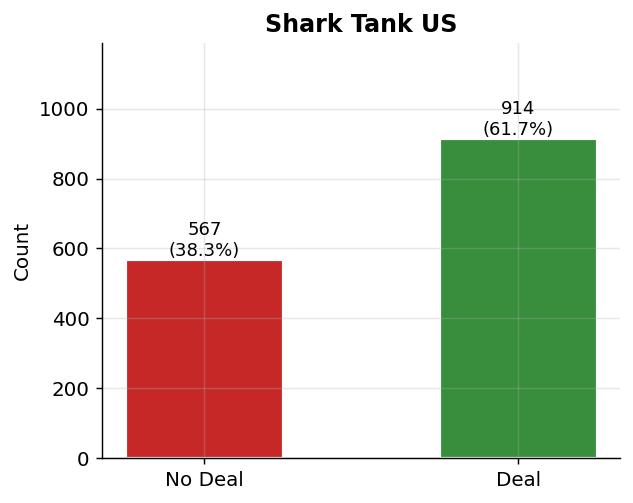

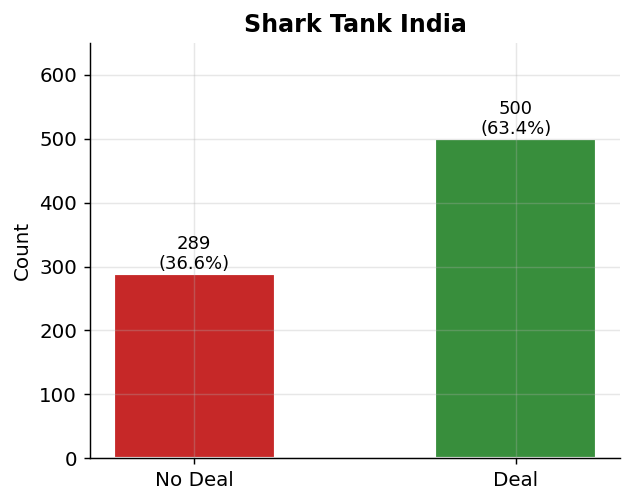

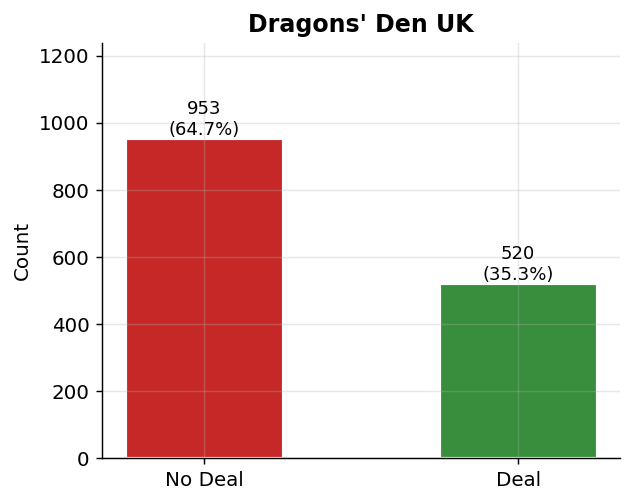

In [7]:
# class distribution - deal vs no deal for all market
eda_frames = {}
for market, df in raw_datasets.items():
    tcol = target_col_map.get(market)
    if tcol:
        tmp = df.copy()
        tmp['target'] = tmp[tcol].apply(to_binary)
        eda_frames[market] = tmp.dropna(subset=['target'])

for market, df_eda in eda_frames.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    counts = df_eda['target'].value_counts().sort_index()
    clrs = ['#C62828', '#388E3C']  # red = no deal, green = deal
    bars = ax.bar(['No Deal', 'Deal'], counts.values, color=clrs,
                  edgecolor='white', linewidth=1.2, width=0.5)
    for bar, val in zip(bars, counts.values):
        pct = val / counts.sum() * 100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(market_labels[market], fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max()*1.3)
    plt.tight_layout()
    plt.savefig(f'fig_eda_class_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

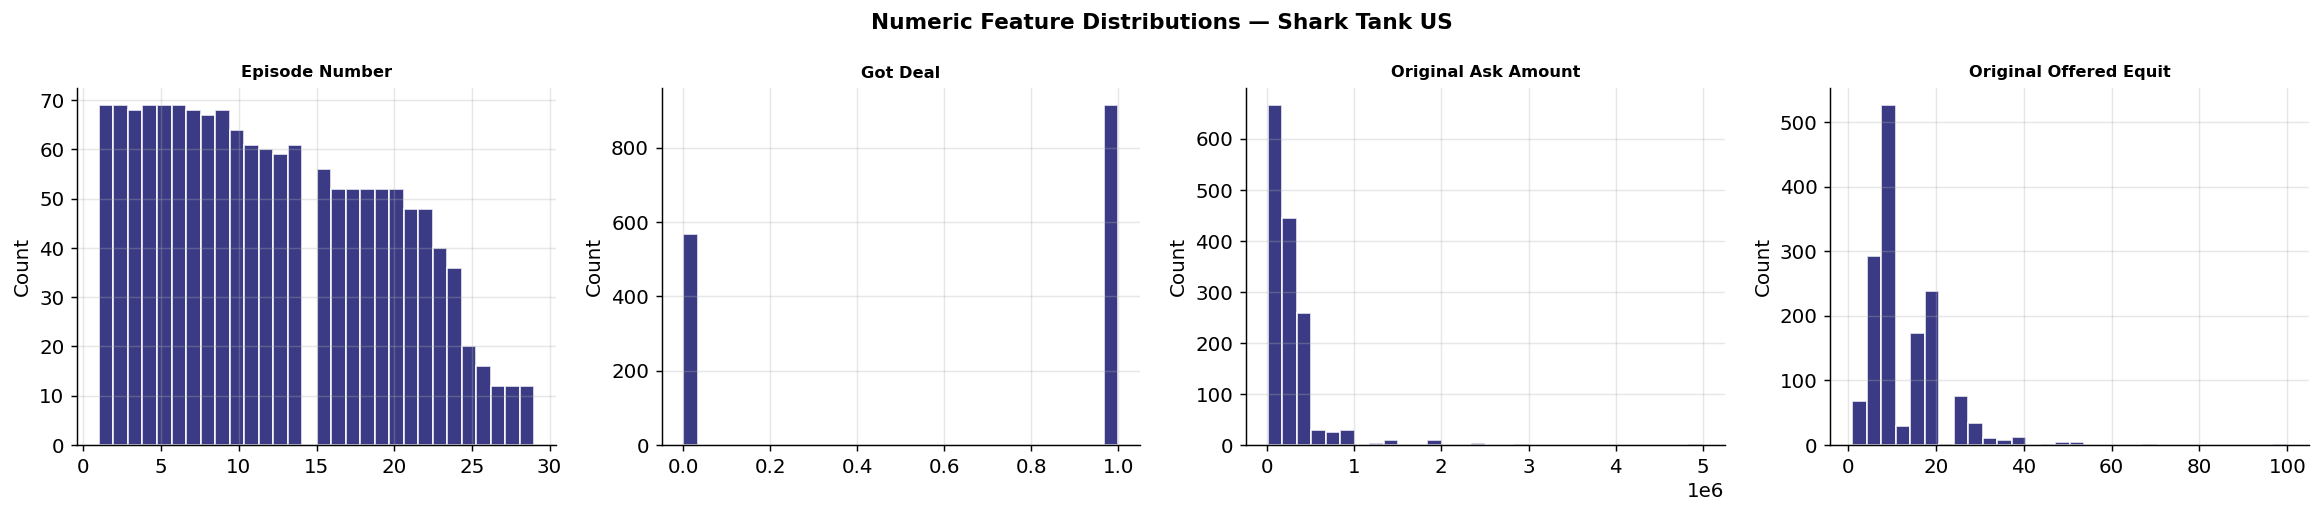

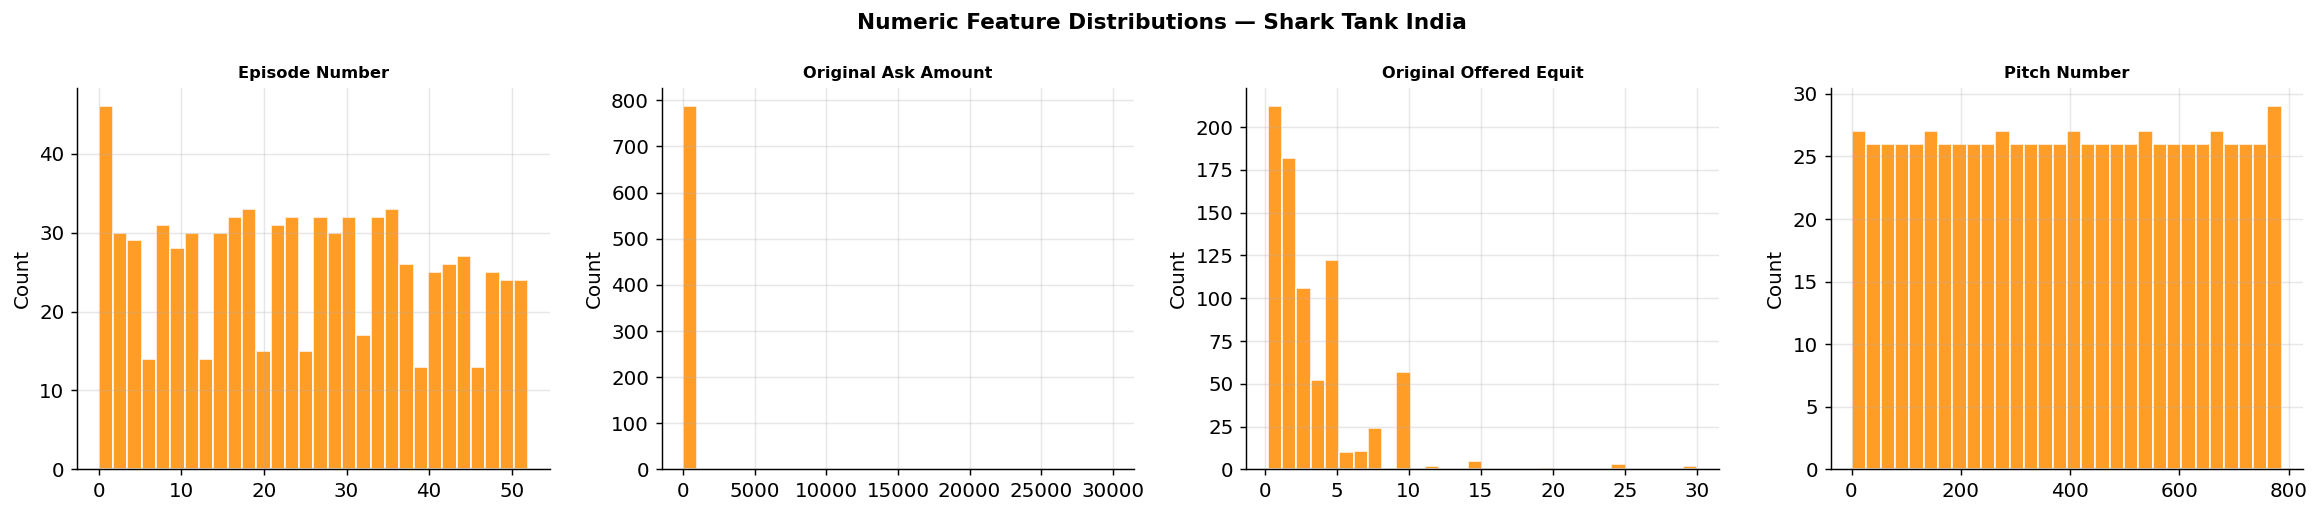

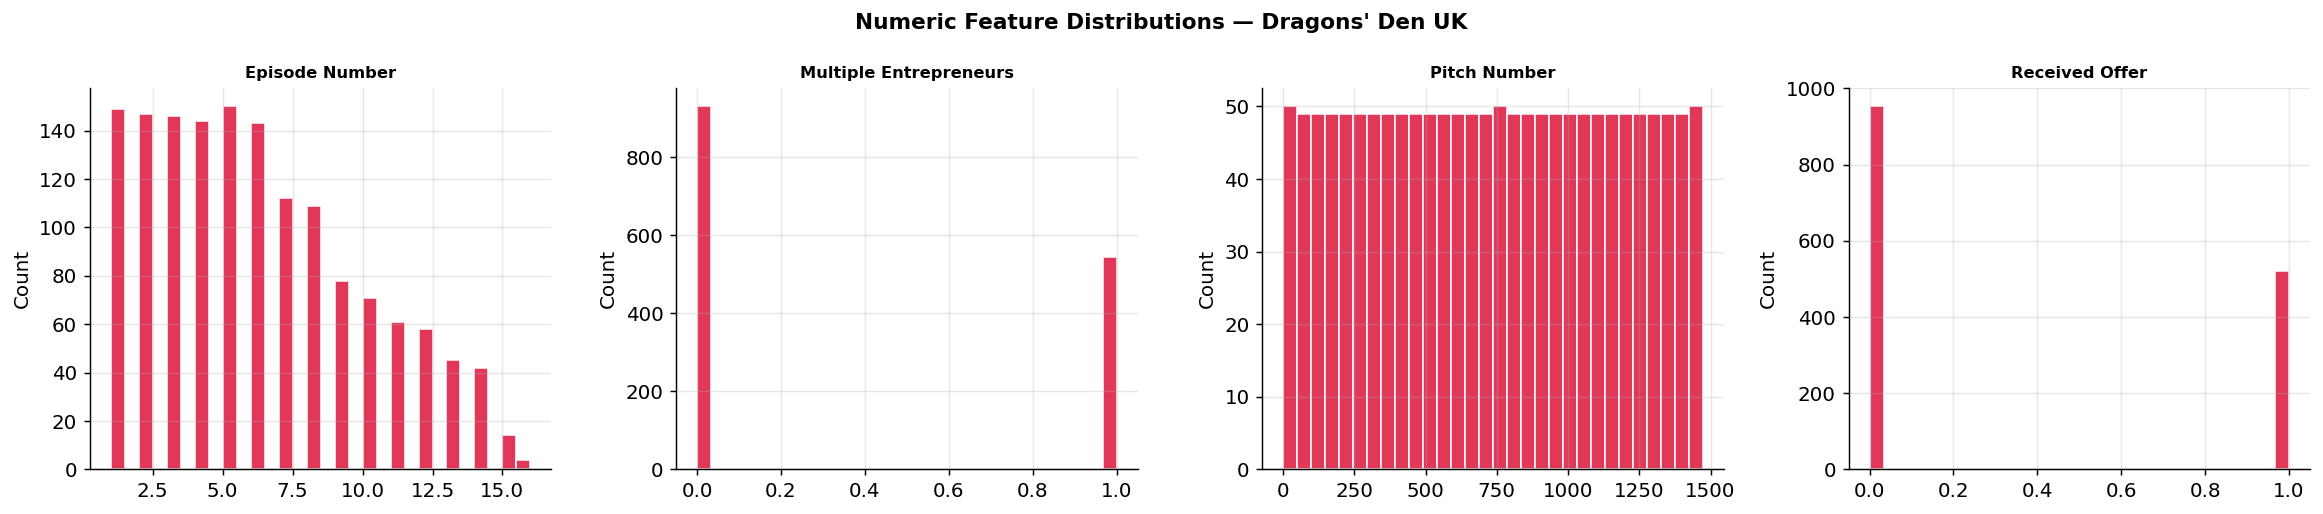

In [8]:
for market, df_eda in eda_frames.items():
    num_cols = (df_eda.select_dtypes(include='number')
                .columns.difference(['target']).tolist())
    num_cols = sorted(num_cols, key=lambda c: df_eda[c].isna().sum())[:4]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Numeric Feature Distributions — {market_labels[market]}',
                 fontsize=12, fontweight='bold')
    for col_idx in range(4):
        ax = axes[col_idx]
        if col_idx < len(num_cols):
            col  = num_cols[col_idx]
            data = df_eda[col].dropna()
            ax.hist(data, bins=30, color=MARKET_COLORS[market],
                    edgecolor='white', alpha=0.85)
            ax.set_title(col[:22], fontsize=9, fontweight='bold')
            ax.set_ylabel('Count')
        else:
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'fig_eda_distributions_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [9]:
# find Target Variable 
for market, df in raw_datasets.items():
    tcol = target_col_map.get(market)
    if tcol:
        tmp = df[tcol].apply(to_binary).dropna()
        d, nd = int(tmp.sum()), int((tmp==0).sum())
        print(f"{market_labels[market]}")
        print(f"target col  : '{tcol}'")
        print(f"deals       : {d}  ({tmp.mean()*100:.1f}%)")
        print(f"no deals    : {nd}  ({(1-tmp.mean())*100:.1f}%)")
        print(f"imbalance   : {nd/max(d,1):.2f}:1")
        print()

Shark Tank US
target col  : 'Got Deal'
deals       : 914  (61.7%)
no deals    : 567  (38.3%)
imbalance   : 0.62:1

Shark Tank India
target col  : 'Received Offer'
deals       : 500  (63.4%)
no deals    : 289  (36.6%)
imbalance   : 0.58:1

Dragons' Den UK
target col  : 'Received Offer'
deals       : 520  (35.3%)
no deals    : 953  (64.7%)
imbalance   : 1.83:1



In [10]:
# Data Preprocessing

# US data prep
print("Shark Tank US")

us_df = raw_datasets['US'].copy().drop_duplicates().reset_index(drop=True)
print(f"rows after dedup : {len(us_df)}")

us_target_col = target_col_map.get('US')
if us_target_col is None or us_target_col not in us_df.columns:
    fb = [c for c in us_df.columns if 'deal' in c.lower() or 'got' in c.lower()]
    us_target_col = fb[0] if fb else None
if us_target_col is None:
    raise KeyError(f"US target not found. Columns: {us_df.columns.tolist()[:10]}")
print(f"target col       : '{us_target_col}'")

us_df['target'] = us_df[us_target_col].apply(to_binary)
us_df = us_df.dropna(subset=['target']).reset_index(drop=True)
print(f"deals / no-deals : {int(us_df['target'].sum())} / {int((us_df['target']==0).sum())}")

Leakage_us = [c for c in [
    'Total Deal Amount','Total Deal Equity','Deal Valuation',
    'Number of Sharks in Deal','Investment Amount Per Shark','Equity Per Shark',
    'Barbara Corcoran Investment Amount','Barbara Corcoran Investment Equity',
    'Mark Cuban Investment Amount','Mark Cuban Investment Equity',
    'Lori Greiner Investment Amount','Lori Greiner Investment Equity',
    'Robert Herjavec Investment Amount','Robert Herjavec Investment Equity',
    'Daymond John Investment Amount','Daymond John Investment Equity',
    'Kevin O Leary Investment Amount','Kevin O Leary Investment Equity',
    'Guest Investment Amount','Guest Investment Equity',
] if c in us_df.columns]
us_df = us_df.drop(columns=Leakage_us + [us_target_col], errors='ignore')

junk_us = [c for c in us_df.columns if any(
    p in c.lower() for p in ['name','title','description','website','url',
                              'pitchers','founder','date','season','episode','air'])]
us_df = us_df.drop(columns=junk_us, errors='ignore')
print(f"dropped leakage  : {len(Leakage_us)} cols")

X_us = us_df.drop(columns=['target'])
y_us = us_df['target'].astype(int)

cat_us = X_us.select_dtypes(include='object').columns.tolist()
if cat_us:
    X_us = pd.get_dummies(X_us, columns=cat_us, drop_first=True)

for col in X_us.columns:
    if X_us[col].isna().any():
        med = X_us[col].median()
        X_us[col] = X_us[col].fillna(0 if pd.isna(med) else med)
X_us = X_us.fillna(0)
print(f"final shape      : {X_us.shape[0]} rows x {X_us.shape[1]} features")
print(f"deal rate        : {y_us.mean()*100:.1f}%")

Shark Tank US
rows after dedup : 1485
target col       : 'Got Deal'
deals / no-deals : 914 / 567
dropped leakage  : 20 cols
final shape      : 1481 rows x 30 features
deal rate        : 61.7%


In [11]:
# india data prep
print("Shark Tank India")

india_df = raw_datasets['India'].copy().drop_duplicates().reset_index(drop=True)
print(f"rows after dedup : {len(india_df)}")

india_target_col = target_col_map.get('India')
if india_target_col is None or india_target_col not in india_df.columns:
    fb = [c for c in india_df.columns if 'offer' in c.lower() or 'deal' in c.lower()]
    india_target_col = fb[0] if fb else None
if india_target_col is None:
    raise KeyError(f"India target not found. Columns: {india_df.columns.tolist()[:10]}")
print(f"target col       : '{india_target_col}'")

india_df['target'] = india_df[india_target_col].apply(to_binary)
india_df = india_df.dropna(subset=['target']).reset_index(drop=True)
print(f"deals / no-deals : {int(india_df['target'].sum())} / {int((india_df['target']==0).sum())}")

# leakage_india = [c for c in [
#     'Quoted Investment','Offered Equity','Offered Investment','Total Investment',
#     'Total Equity','Accepted Offer',
#     'Namita Investment','Namita Equity','Anupam Investment','Anupam Equity',
#     'Vineeta Investment','Vineeta Equity','Ashneer Investment','Ashneer Equity',
#     'Peyush Investment','Peyush Equity','Ghazal Investment','Ghazal Equity',
#     'Aman Investment','Aman Equity',
# ] if c in india_df.columns]

leakage_india = [c for c in [
    'Quoted Investment','Offered Equity','Offered Investment',
    'Total Investment','Total Equity','Accepted Offer',
    'Namita Investment','Namita Equity','Anupam Investment','Anupam Equity',
    'Vineeta Investment','Vineeta Equity','Ashneer Investment','Ashneer Equity',
    'Peyush Investment','Peyush Equity','Ghazal Investment','Ghazal Equity',
    'Aman Investment','Aman Equity',
    'Total Deal Amount','Total Deal Equity','Total Deal Debt','Debt Interest',
] if c in india_df.columns]

india_df = india_df.drop(columns=leakage_india + [india_target_col], errors='ignore')

junk_india = [c for c in india_df.columns if any(
    p in c.lower() for p in ['name','title','description','website','url',
                              'founder','date','season','episode'])]
india_df = india_df.drop(columns=junk_india, errors='ignore')
print(f"dropped leakage  : {len(leakage_india)} cols")

X_india = india_df.drop(columns=['target'], errors='ignore')
y_india = india_df['target'].astype(int)

Cat_india = X_india.select_dtypes(include='object').columns.tolist()
if Cat_india:
    X_india = pd.get_dummies(X_india, columns=Cat_india, drop_first=True)

for col in X_india.columns:
    if X_india[col].isna().any():
        med = X_india[col].median()
        X_india[col] = X_india[col].fillna(0 if pd.isna(med) else med)
X_india = X_india.fillna(0)
print(f"final shape      : {X_india.shape[0]} rows x {X_india.shape[1]} features")
print(f"deal rate        : {y_india.mean()*100:.1f}%")

Shark Tank India
rows after dedup : 789
target col       : 'Received Offer'
deals / no-deals : 500 / 289
dropped leakage  : 5 cols
final shape      : 789 rows x 295 features
deal rate        : 63.4%


In [12]:
# UK data prep
print("Dragons' Den UK")

uk_df = raw_datasets['UK'].copy().drop_duplicates().reset_index(drop=True)
print(f"rows after dedup : {len(uk_df)}")

uk_target_col = target_col_map.get('UK')
if uk_target_col is None or uk_target_col not in uk_df.columns:
    fb = [c for c in uk_df.columns if 'deal' in c.lower() or 'invest' in c.lower()]
    uk_target_col = fb[0] if fb else None
if uk_target_col is None:
    raise KeyError(f"UK target not found. Columns: {uk_df.columns.tolist()[:10]}")
print(f"target col       : '{uk_target_col}'")

uk_df['target'] = uk_df[uk_target_col].apply(to_binary)
uk_df = uk_df.dropna(subset=['target']).reset_index(drop=True)
print(f"deals / no-deals : {int(uk_df['target'].sum())} / {int((uk_df['target']==0).sum())}")

# leakage_uk = [c for c in [
#     'Investment Offered','Equity Offered','Royalty','Outcome',
#     'Total Investment','Investment Per Dragon','Number of Dragons',
#     'Dragon 1 Investment','Dragon 2 Investment','Dragon 3 Investment',
#     'Dragon 4 Investment','Dragon 5 Investment',
# ] if c in uk_df.columns]

leakage_uk = [c for c in [
    'Investment Offered','Equity Offered','Royalty','Outcome',
    'Total Investment','Investment Per Dragon','Number of Dragons',
    'Dragon 1 Investment','Dragon 2 Investment','Dragon 3 Investment',
    'Dragon 4 Investment','Dragon 5 Investment',
    'Accepted Offer','Deal Successful','Total Deal Amount','Total Deal Equity',
    'Deal Valuation','Number of Dragons in Deal','Investment Amount Per Dragon',
    'Equity Per Dragon','Royalty Deal','Advisory Shares Equity','Loan',
    'Peter Jones Investment Amount','Investor Names','Dragons Investing'
] if c in uk_df.columns]

uk_df = uk_df.drop(columns=leakage_uk + [uk_target_col], errors='ignore')

junk_uk = [c for c in uk_df.columns if any(
    p in c.lower() for p in ['name','title','description','website','url',
                              'founder','date','series','episode'])]
uk_df = uk_df.drop(columns=junk_uk, errors='ignore')
print(f"dropped leakage  : {len(leakage_uk)} cols")

X_uk = uk_df.drop(columns=['target'], errors='ignore')
y_uk = uk_df['target'].astype(int)

cat_uk = X_uk.select_dtypes(include='object').columns.tolist()
if cat_uk:
    X_uk = pd.get_dummies(X_uk, columns=cat_uk, drop_first=True)

for col in X_uk.columns:
    if X_uk[col].isna().any():
        med = X_uk[col].median()
        X_uk[col] = X_uk[col].fillna(0 if pd.isna(med) else med)
X_uk = X_uk.fillna(0)
print(f"final shape      : {X_uk.shape[0]} rows x {X_uk.shape[1]} features")
print(f"deal rate        : {y_uk.mean()*100:.1f}%")

Dragons' Den UK
rows after dedup : 1473
target col       : 'Received Offer'
deals / no-deals : 520 / 953
dropped leakage  : 12 cols
final shape      : 1473 rows x 89 features
deal rate        : 35.3%


In [13]:
# Finish Preprocessing
summary = pd.DataFrame([
    {'Market':'Shark Tank US',   'Samples':len(X_us),
     'Features':X_us.shape[1],  'Deals':int(y_us.sum()),
     'No Deals':int((y_us==0).sum()), 'Deal %':f'{y_us.mean()*100:.1f}%',
     'Imbalance':f'{(y_us==0).sum()/max(y_us.sum(),1):.2f}:1'},
    {'Market':'Shark Tank India','Samples':len(X_india),
     'Features':X_india.shape[1],'Deals':int(y_india.sum()),
     'No Deals':int((y_india==0).sum()),'Deal %':f'{y_india.mean()*100:.1f}%',
     'Imbalance':f'{(y_india==0).sum()/max(y_india.sum(),1):.2f}:1'},
    {'Market':"Dragons' Den UK", 'Samples':len(X_uk),
     'Features':X_uk.shape[1],  'Deals':int(y_uk.sum()),
     'No Deals':int((y_uk==0).sum()), 'Deal %':f'{y_uk.mean()*100:.1f}%',
     'Imbalance':f'{(y_uk==0).sum()/max(y_uk.sum(),1):.2f}:1'},
])
print(summary.to_string(index=False))
print("\nall markets ready for training")

          Market  Samples  Features  Deals  No Deals Deal % Imbalance
   Shark Tank US     1481        30    914       567  61.7%    0.62:1
Shark Tank India      789       295    500       289  63.4%    0.58:1
 Dragons' Den UK     1473        89    520       953  35.3%    1.83:1

all markets ready for training


In [14]:
# Need to start model training

# made common function for training
def train_all_models(X, y, market_name, use_smote=False, verbose=True):
    # trains 4 classifiers with stratified k-fold cv
    if verbose:
        print(f"\n{market_name}")
        print("")

    X_arr = X.values if isinstance(X, pd.DataFrame) else np.array(X)
    y_arr = y.values if isinstance(y, pd.Series) else np.array(y)
    feat_names = list(X.columns) if isinstance(X, pd.DataFrame) else [f'f{i}' for i in range(X_arr.shape[1])]

    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, y_arr, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y_arr)

    if use_smote:
        u, c = np.unique(y_train, return_counts=True)
        if len(u) >= 2 and c.min() > 1:
            X_train, y_train = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
            if verbose:
                print(f"smote applied: {len(X_train)} training samples")

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                      random_state=RANDOM_STATE),
        'SVM':                 SVC(kernel='rbf', probability=True, class_weight='balanced',
                                   random_state=RANDOM_STATE),
        'XGBoost':             xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                                  eval_metric='logloss',
                                                  random_state=RANDOM_STATE, verbosity=0),
    }

    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    results = {}

    if verbose:
        print(f"\n  {'Model':<22} {'Acc':>6} {'F1':>6} {'AUC':>6}  {'CV-F1 (mean+/-std)':>22}  {'Opt.Thresh':>10}")
        print(f"{'-'*80}")

    for mname, model in models.items():
        try:
            cv_fold_scores = cross_val_score(model, X_tr, y_train,
                                             cv=skf, scoring='f1', n_jobs=-1)
        except Exception:
            cv_fold_scores = np.array([float('nan')] * CV_FOLDS)

        model.fit(X_tr, y_train)
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        # find optimal threshold using precision-recall curve
        precs, recs, threshs = precision_recall_curve(y_test, y_proba)
        f1s = 2 * precs * recs / (precs + recs + 1e-9)
        if len(threshs) > 0:
            best_i  = np.argmax(f1s[:-1])
            opt_thr = float(threshs[best_i])
        else:
            opt_thr = 0.5
        y_pred_opt = (y_proba >= opt_thr).astype(int)

        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            auc = float('nan')
        f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)
        brier  = brier_score_loss(y_test, y_proba)

        results[mname] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':   recall_score(y_test, y_pred, zero_division=0),
            'F1':       f1,
            'ROC-AUC':  auc,
            'CV_F1_mean':   cv_fold_scores.mean(),
            'CV_F1_std':    cv_fold_scores.std(),
            'CV_fold_scores': cv_fold_scores,
            'Opt_Threshold':  opt_thr,
            'F1_at_OptThresh': f1_opt,
            'Brier_Score':    brier,
            'model': model, 'scaler': scaler, 'feature_names': feat_names,
            'X_test': X_te, 'y_test': y_test,
            'y_pred': y_pred, 'y_proba': y_proba, 'y_pred_opt': y_pred_opt,
        }

        if verbose:
            print(f"{mname:<22} {acc:>6.4f} {f1:>6.4f} {auc:>6.4f}"
                  f"{cv_fold_scores.mean():.4f} +/- {cv_fold_scores.std():.4f}"
                  f"{opt_thr:>10.3f}")

    if verbose:
        print(f"\n  done: {market_name}")
    return results

print("train_all_models function is ready now.")

train_all_models function is ready now.


In [15]:
# US training

market_data = {
    'US':    (X_us,    y_us),
    'India': (X_india, y_india),
    'UK':    (X_uk,    y_uk),
}

results_us = train_all_models(
    X_us, y_us, 'Shark Tank US', use_smote=False, verbose=True
)


Shark Tank US


  Model                     Acc     F1    AUC      CV-F1 (mean+/-std)  Opt.Thresh
--------------------------------------------------------------------------------
Logistic Regression    0.6330 0.7471 0.59990.7374 +/- 0.0204     0.316
Random Forest          0.5354 0.6406 0.51800.6962 +/- 0.0192     0.165
SVM                    0.5556 0.6250 0.57010.6509 +/- 0.0297     0.454
XGBoost                0.5286 0.6447 0.54730.7044 +/- 0.0115     0.244

  done: Shark Tank US


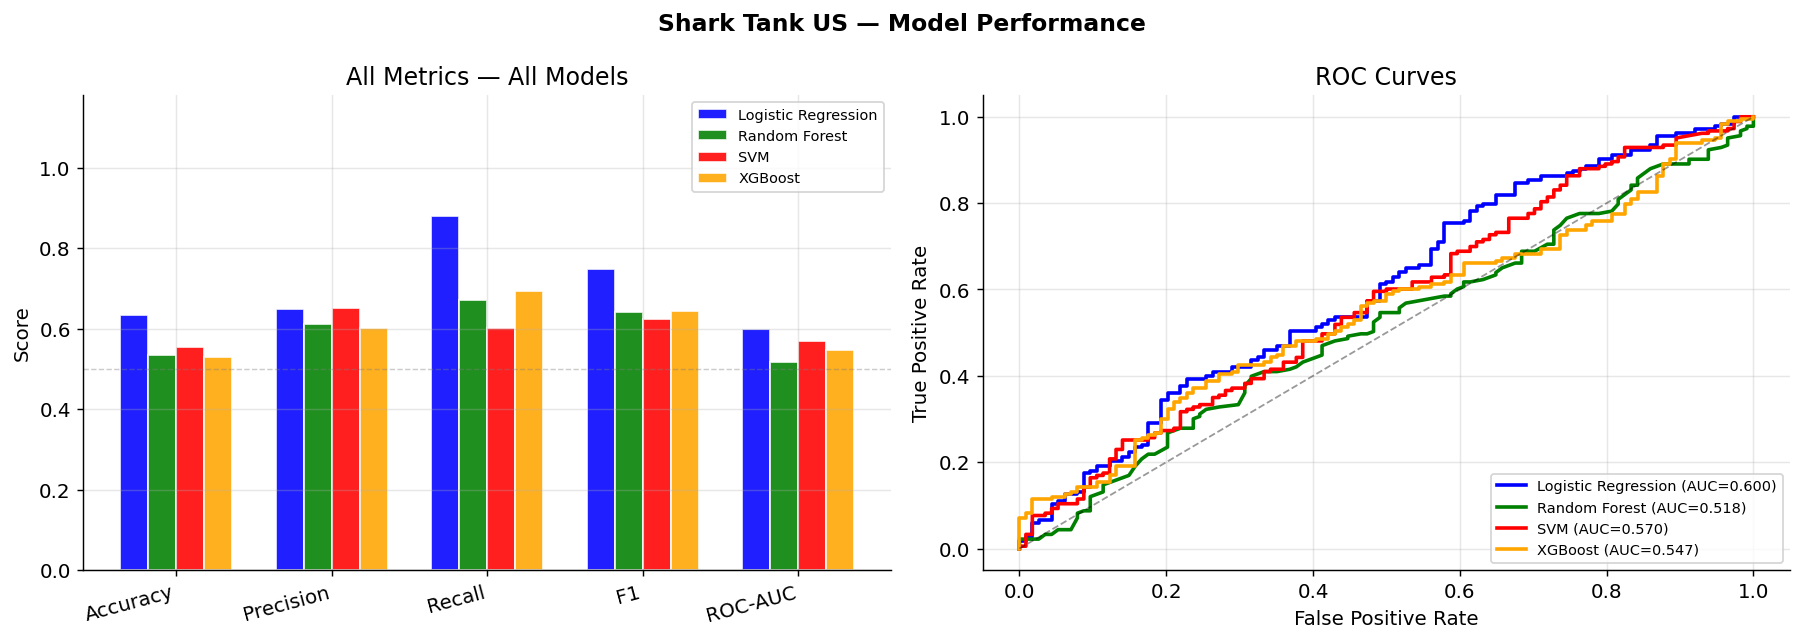

In [16]:

# US metrics and ROC Diagram

mres = results_us
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shark Tank US — Model Performance', fontsize=13, fontweight='bold')

metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics)); w = 0.18
for i, (mname, mc) in enumerate(PALETTE.items()):
    vals = [mres[mname][m] for m in metrics]
    ax1.bar(x + (i-1.5)*w, vals, w, label=mname, color=mc, alpha=0.88, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(metrics, rotation=15, ha='right')
ax1.set_ylim(0, 1.18); ax1.set_ylabel('Score')
ax1.set_title('All Metrics — All Models')
ax1.legend(fontsize=8); ax1.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.4)

for mname, mc in PALETTE.items():
    m = mres[mname]
    try:
        fpr, tpr, _ = roc_curve(m['y_test'], m['y_proba'])
        ax2.plot(fpr, tpr, color=mc, lw=2, label=f"{mname} (AUC={m['ROC-AUC']:.3f})")
    except Exception:
        pass
ax2.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves'); ax2.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig_us_performance.png', dpi=150, bbox_inches='tight')
plt.show()

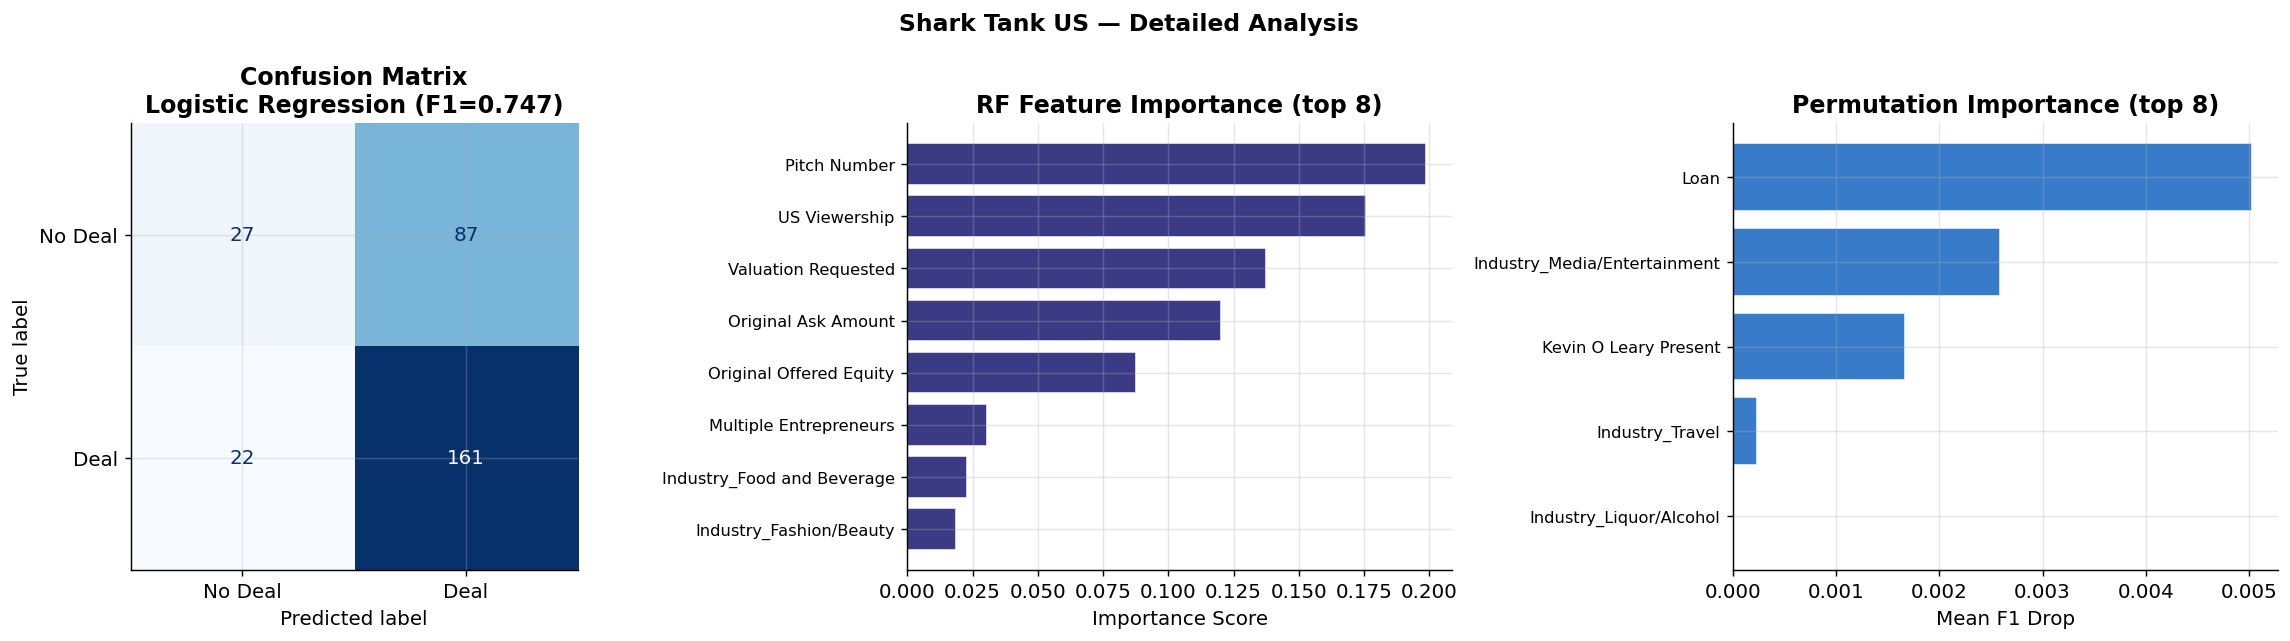

best model: Logistic Regression | F1: 0.7471 | AUC: 0.5999


In [17]:


# US confusion matrix + feature importance
mres = results_us
best_name = max(mres, key=lambda k: mres[k]['F1'])
best      = mres[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Shark Tank US — Detailed Analysis', fontsize=13, fontweight='bold')

cm   = confusion_matrix(best['y_test'], best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Deal','Deal'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} (F1={best["F1"]:.3f})', fontweight='bold')

feat_names = mres['Random Forest']['feature_names']
rf_imp = pd.Series(mres['Random Forest']['model'].feature_importances_, index=feat_names)
rf_top = rf_imp.sort_values(ascending=False).head(8)
y_pos  = range(len(rf_top))
axes[1].barh(y_pos, rf_top.values, color=MARKET_COLORS['US'], alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos); axes[1].set_yticklabels([f[:30] for f in rf_top.index], fontsize=9)
axes[1].invert_yaxis(); axes[1].set_title('RF Feature Importance (top 8)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

perm = permutation_importance(
    mres['Random Forest']['model'], best['X_test'], best['y_test'],
    n_repeats=15, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feat_names)
perm_top = perm_imp[perm_imp > 0].sort_values(ascending=False).head(8)
if len(perm_top):
    yp = range(len(perm_top))
    axes[2].barh(yp, perm_top.values, color='#1565C0', alpha=0.85, edgecolor='white')
    axes[2].set_yticks(yp); axes[2].set_yticklabels([f[:30] for f in perm_top.index], fontsize=9)
    axes[2].invert_yaxis()
else:
    axes[2].text(0.5, 0.5, 'No positive\npermutation values',
                 ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_title('Permutation Importance (top 8)', fontweight='bold')
axes[2].set_xlabel('Mean F1 Drop')

if 'importance_results' not in dir():
    importance_results = {}
importance_results['US'] = {'RF': rf_top, 'Perm': perm_top}

plt.tight_layout()
plt.savefig('fig_us_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"best model: {best_name} | F1: {best['F1']:.4f} | AUC: {best['ROC-AUC']:.4f}")

In [18]:
# India training

market_data = {
    'US':    (X_us,    y_us),
    'India': (X_india, y_india),
    'UK':    (X_uk,    y_uk),
}

results_india = train_all_models(
    X_india, y_india, 'Shark Tank India', use_smote=False, verbose=True
)


Shark Tank India


  Model                     Acc     F1    AUC      CV-F1 (mean+/-std)  Opt.Thresh
--------------------------------------------------------------------------------
Logistic Regression    0.6835 0.7596 0.75470.7503 +/- 0.0385     0.366
Random Forest          0.9051 0.9189 0.95600.9285 +/- 0.0229     0.465
SVM                    0.6139 0.6303 0.72710.6550 +/- 0.0420     0.415
XGBoost                0.9114 0.9263 0.94360.9136 +/- 0.0135     0.522

  done: Shark Tank India


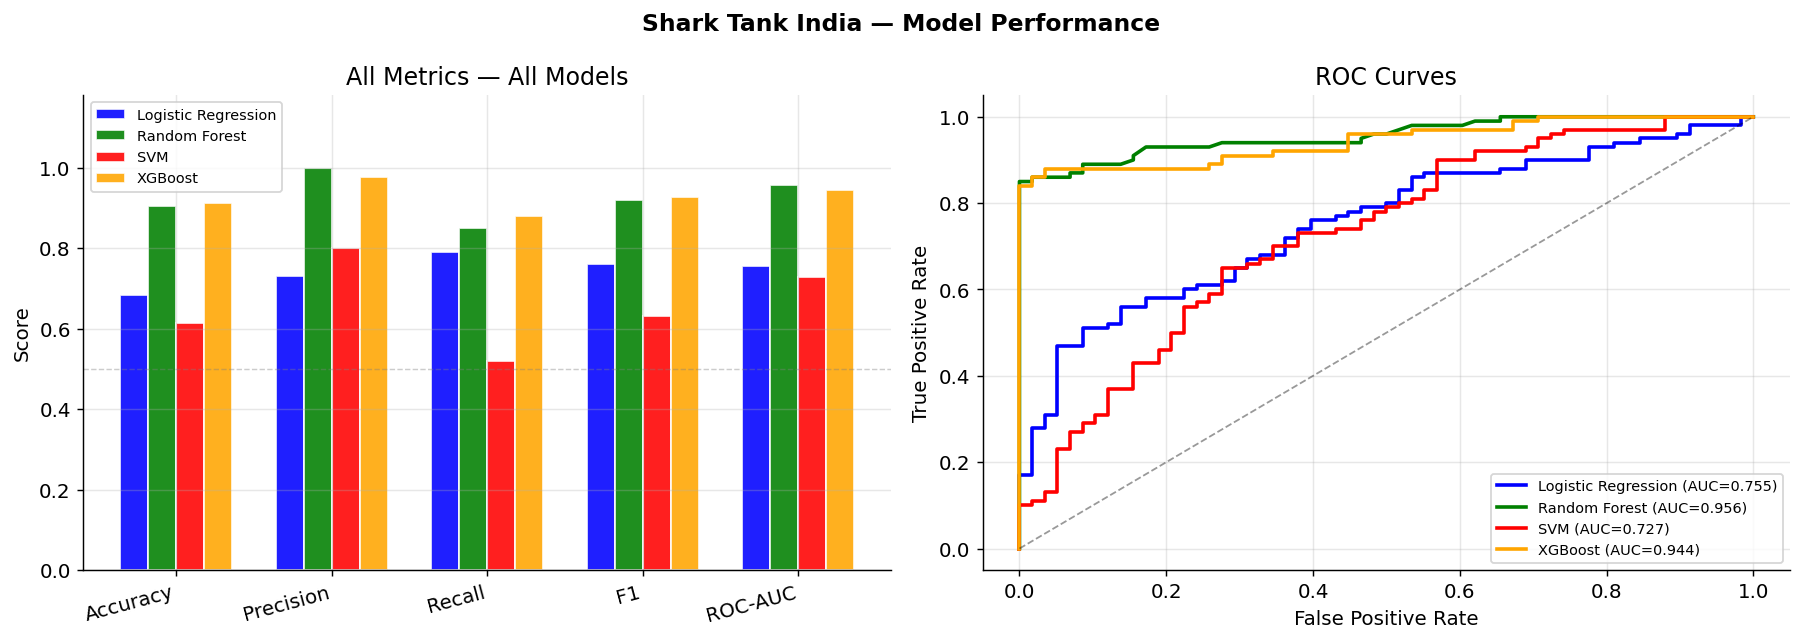

In [19]:
# India metrics + ROC
mres = results_india
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shark Tank India — Model Performance', fontsize=13, fontweight='bold')

metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics)); w = 0.18
for i, (mname, mc) in enumerate(PALETTE.items()):
    vals = [mres[mname][m] for m in metrics]
    ax1.bar(x + (i-1.5)*w, vals, w, label=mname, color=mc, alpha=0.88, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(metrics, rotation=15, ha='right')
ax1.set_ylim(0, 1.18); ax1.set_ylabel('Score')
ax1.set_title('All Metrics — All Models')
ax1.legend(fontsize=8); ax1.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.4)

for mname, mc in PALETTE.items():
    m = mres[mname]
    try:
        fpr, tpr, _ = roc_curve(m['y_test'], m['y_proba'])
        ax2.plot(fpr, tpr, color=mc, lw=2, label=f"{mname} (AUC={m['ROC-AUC']:.3f})")
    except Exception:
        pass
ax2.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves'); ax2.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig_india_performance.png', dpi=150, bbox_inches='tight')
plt.show()

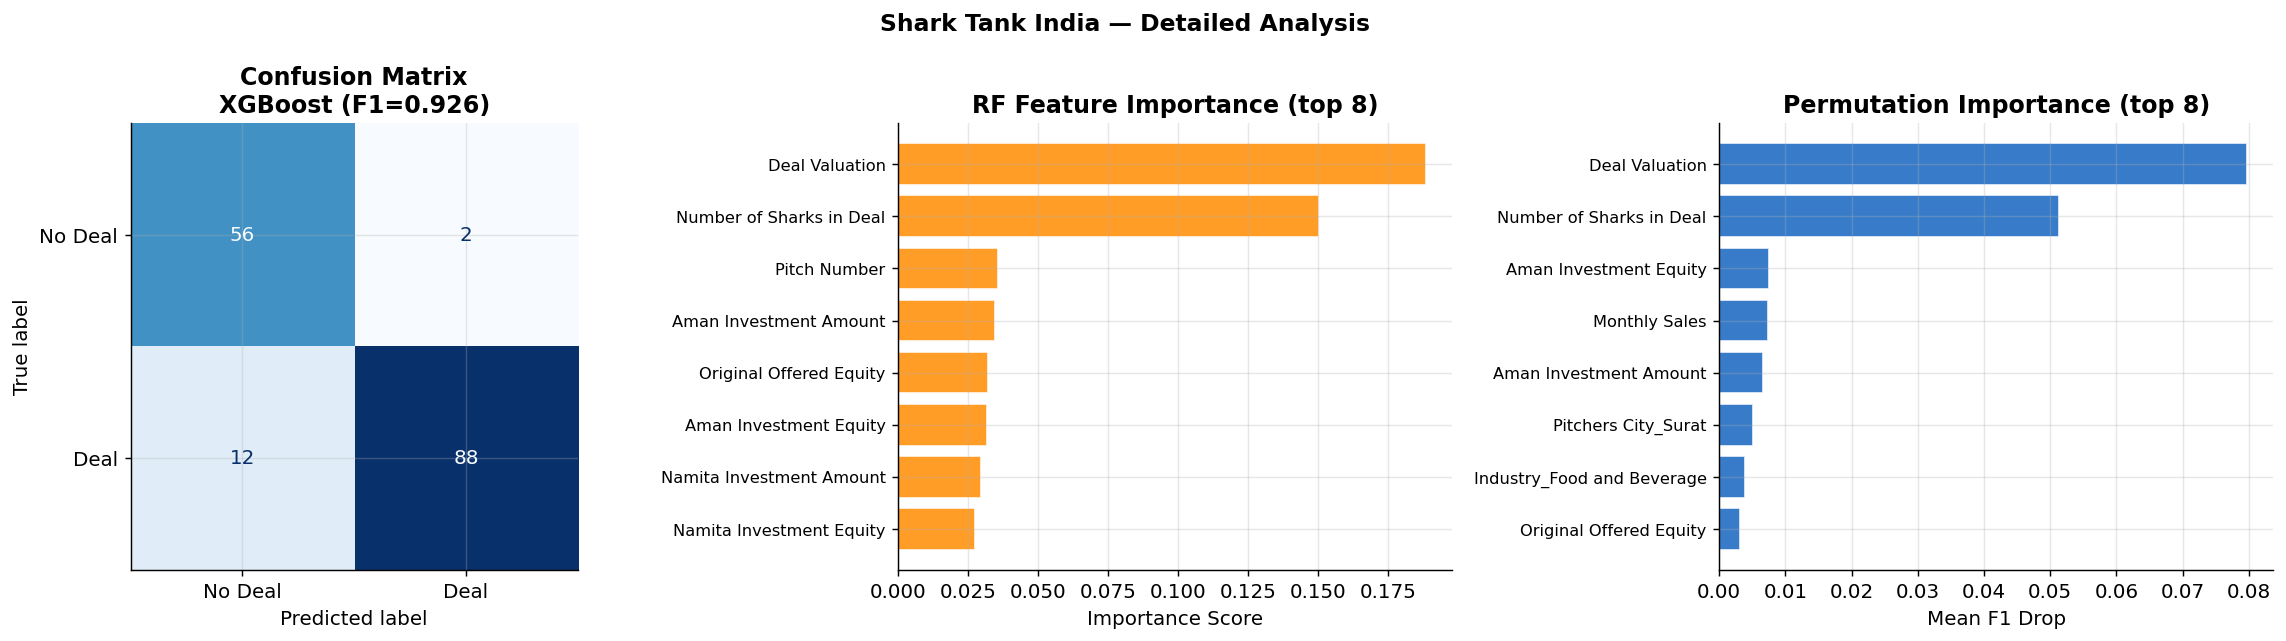

best model: XGBoost | F1: 0.9263 | AUC: 0.9436


In [20]:
# India confusion matrix and Feature Importance
mres = results_india
best_name = max(mres, key=lambda k: mres[k]['F1'])
best      = mres[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Shark Tank India — Detailed Analysis', fontsize=13, fontweight='bold')

cm   = confusion_matrix(best['y_test'], best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Deal','Deal'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} (F1={best["F1"]:.3f})', fontweight='bold')

feat_names = mres['Random Forest']['feature_names']
rf_imp = pd.Series(mres['Random Forest']['model'].feature_importances_, index=feat_names)
rf_top = rf_imp.sort_values(ascending=False).head(8)
y_pos  = range(len(rf_top))
axes[1].barh(y_pos, rf_top.values, color=MARKET_COLORS['India'], alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos); axes[1].set_yticklabels([f[:30] for f in rf_top.index], fontsize=9)
axes[1].invert_yaxis(); axes[1].set_title('RF Feature Importance (top 8)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

perm = permutation_importance(
    mres['Random Forest']['model'], best['X_test'], best['y_test'],
    n_repeats=15, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feat_names)
perm_top = perm_imp[perm_imp > 0].sort_values(ascending=False).head(8)
if len(perm_top):
    yp = range(len(perm_top))
    axes[2].barh(yp, perm_top.values, color='#1565C0', alpha=0.85, edgecolor='white')
    axes[2].set_yticks(yp); axes[2].set_yticklabels([f[:30] for f in perm_top.index], fontsize=9)
    axes[2].invert_yaxis()
else:
    axes[2].text(0.5, 0.5, 'No positive\npermutation values',
                 ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_title('Permutation Importance (top 8)', fontweight='bold')
axes[2].set_xlabel('Mean F1 Drop')

if 'importance_results' not in dir():
    importance_results = {}
importance_results['India'] = {'RF': rf_top, 'Perm': perm_top}

plt.tight_layout()
plt.savefig('fig_india_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"best model: {best_name} | F1: {best['F1']:.4f} | AUC: {best['ROC-AUC']:.4f}")

In [21]:
# UK training and results

market_data = {
    'US':    (X_us,    y_us),
    'India': (X_india, y_india),
    'UK':    (X_uk,    y_uk),
}

results_uk = train_all_models(
    X_uk, y_uk, "Dragons' Den UK", use_smote=False, verbose=True
)


Dragons' Den UK


  Model                     Acc     F1    AUC      CV-F1 (mean+/-std)  Opt.Thresh
--------------------------------------------------------------------------------
Logistic Regression    0.8136 0.6995 0.86870.7128 +/- 0.0458     0.291
Random Forest          0.8542 0.7772 0.92670.7942 +/- 0.0294     0.305
SVM                    0.8373 0.7714 0.90740.7721 +/- 0.0440     0.309
XGBoost                0.8610 0.7960 0.92460.8003 +/- 0.0331     0.707

  done: Dragons' Den UK


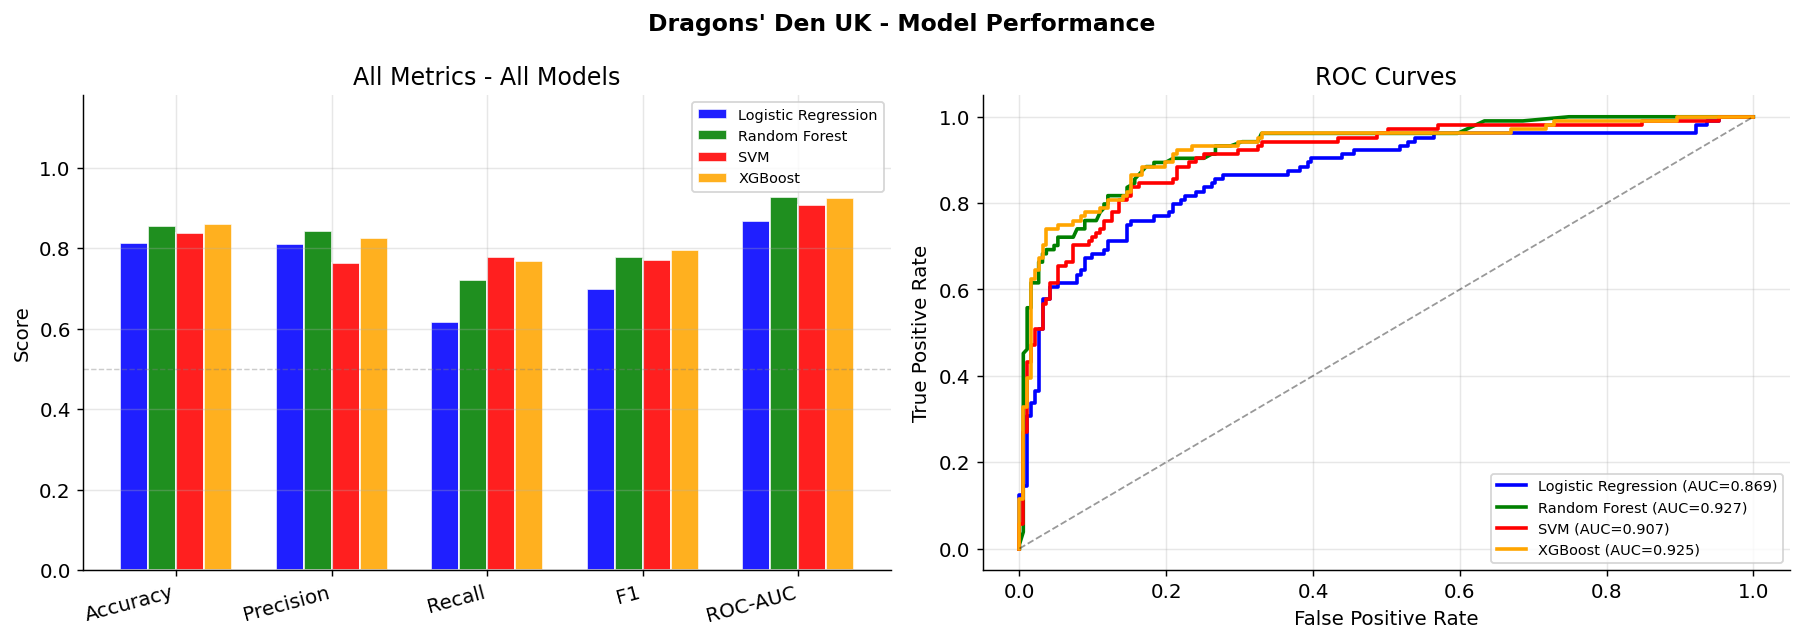

In [22]:
# UK metrics and roc
mres = results_uk
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dragons' Den UK - Model Performance", fontsize=13, fontweight='bold')

metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics)); w = 0.18
for i, (mname, mc) in enumerate(PALETTE.items()):
    vals = [mres[mname][m] for m in metrics]
    ax1.bar(x + (i-1.5)*w, vals, w, label=mname, color=mc, alpha=0.88, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(metrics, rotation=15, ha='right')
ax1.set_ylim(0, 1.18); ax1.set_ylabel('Score')
ax1.set_title('All Metrics - All Models')
ax1.legend(fontsize=8); ax1.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.4)

for mname, mc in PALETTE.items():
    m = mres[mname]
    try:
        fpr, tpr, _ = roc_curve(m['y_test'], m['y_proba'])
        ax2.plot(fpr, tpr, color=mc, lw=2, label=f"{mname} (AUC={m['ROC-AUC']:.3f})")
    except Exception:
        pass
ax2.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves'); ax2.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig_uk_performance.png', dpi=150, bbox_inches='tight')
plt.show()

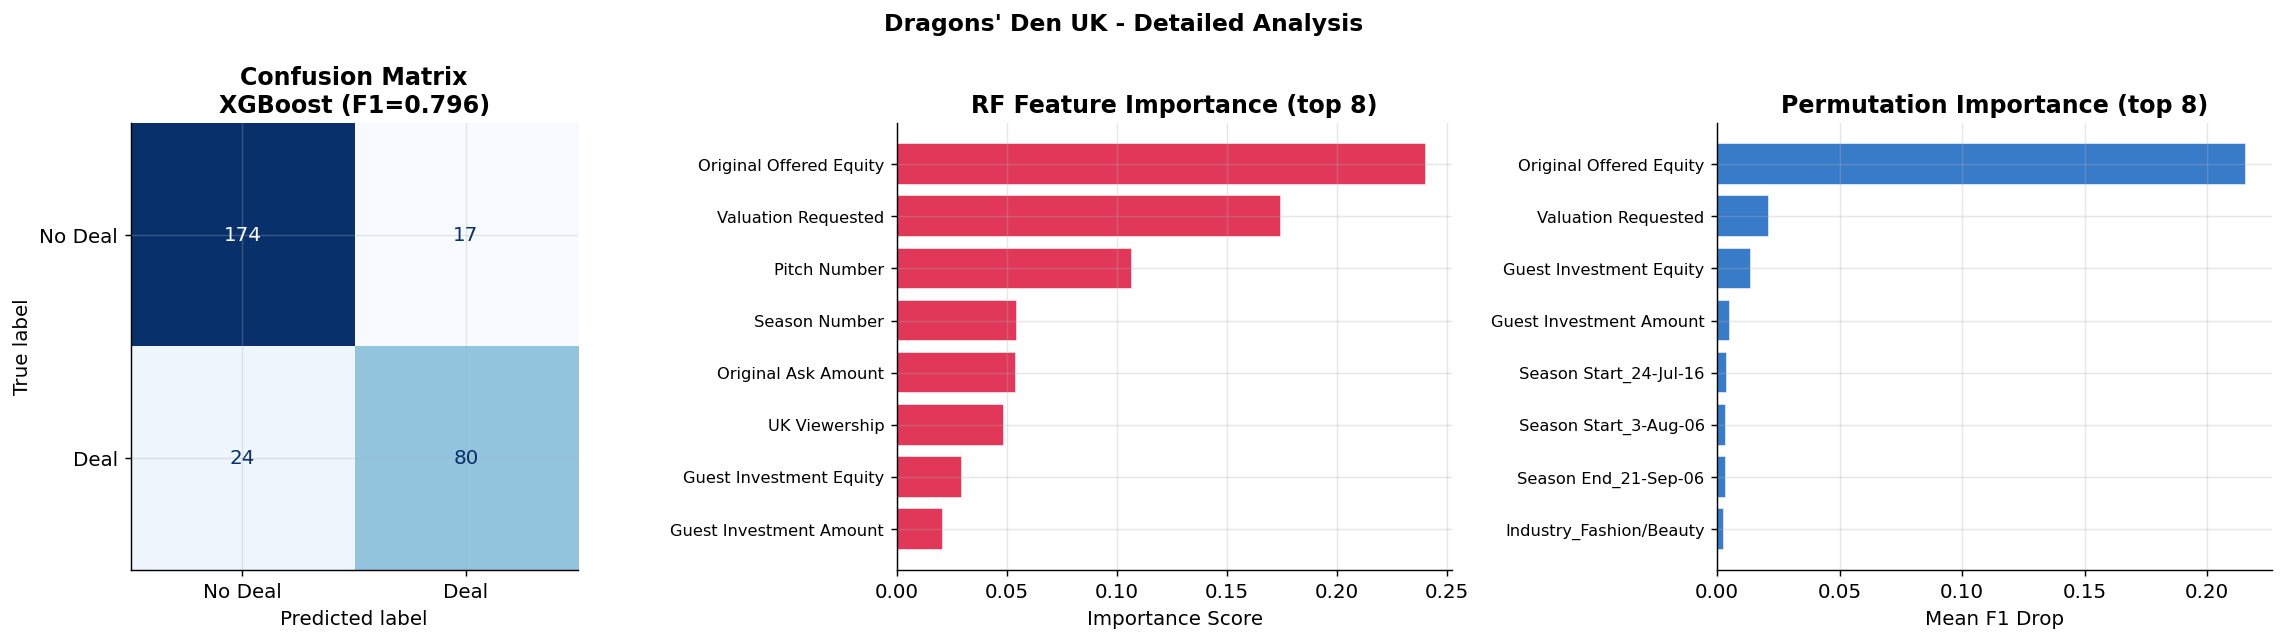

best model: XGBoost | F1: 0.7960 | AUC: 0.9246


In [23]:
# UK confusion matrix + feature importance
mres = results_uk
best_name = max(mres, key=lambda k: mres[k]['F1'])
best      = mres[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Dragons' Den UK - Detailed Analysis", fontsize=13, fontweight='bold')

cm   = confusion_matrix(best['y_test'], best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Deal','Deal'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} (F1={best["F1"]:.3f})', fontweight='bold')

feat_names = mres['Random Forest']['feature_names']
rf_imp = pd.Series(mres['Random Forest']['model'].feature_importances_, index=feat_names)
rf_top = rf_imp.sort_values(ascending=False).head(8)
y_pos  = range(len(rf_top))
axes[1].barh(y_pos, rf_top.values, color=MARKET_COLORS['UK'], alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos); axes[1].set_yticklabels([f[:30] for f in rf_top.index], fontsize=9)
axes[1].invert_yaxis(); axes[1].set_title('RF Feature Importance (top 8)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

perm = permutation_importance(
    mres['Random Forest']['model'], best['X_test'], best['y_test'],
    n_repeats=15, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feat_names)
perm_top = perm_imp[perm_imp > 0].sort_values(ascending=False).head(8)
if len(perm_top):
    yp = range(len(perm_top))
    axes[2].barh(yp, perm_top.values, color='#1565C0', alpha=0.85, edgecolor='white')
    axes[2].set_yticks(yp); axes[2].set_yticklabels([f[:30] for f in perm_top.index], fontsize=9)
    axes[2].invert_yaxis()
else:
    axes[2].text(0.5, 0.5, 'No positive permutation values',
                 ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_title('Permutation Importance (top 8)', fontweight='bold')
axes[2].set_xlabel('Mean F1 Drop')

if 'importance_results' not in dir():
    importance_results = {}
importance_results['UK'] = {'RF': rf_top, 'Perm': perm_top}

plt.tight_layout()
plt.savefig('fig_uk_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"best model: {best_name} | F1: {best['F1']:.4f} | AUC: {best['ROC-AUC']:.4f}")

In [24]:

# all market results
market_results = {
    'US':    results_us,
    'India': results_india,
    'UK':    results_uk,
}

best_model_per_market = {
    m: max(market_results[m], key=lambda k: market_results[m][k]['F1'])
    for m in market_results
}

print("Results Consolidated : ")
for m in ['US','India','UK']:
    best = best_model_per_market[m]
    f1   = market_results[m][best]['F1']
    auc  = market_results[m][best]['ROC-AUC']
    print(f"{market_labels[m]:<22}  best: {best:<22}  F1={f1:.4f}  AUC={auc:.4f}")

Results Consolidated : 
Shark Tank US           best: Logistic Regression     F1=0.7471  AUC=0.5999
Shark Tank India        best: XGBoost                 F1=0.9263  AUC=0.9436
Dragons' Den UK         best: XGBoost                 F1=0.7960  AUC=0.9246


In [25]:
# Cross Market Comparison
rows = []
for market in ['US','India','UK']:
    for mname, m in market_results[market].items():
        rows.append({'Market':market, 'Model':mname,
                     'Accuracy':round(m['Accuracy'],4),
                     'F1':round(m['F1'],4),
                     'ROC-AUC':round(m['ROC-AUC'],4),
                     'CV-F1':round(m['CV_F1_mean'],4),
                     'CV-Std':round(m['CV_F1_std'],4)})
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

Market               Model  Accuracy     F1  ROC-AUC  CV-F1  CV-Std
    US Logistic Regression    0.6330 0.7471   0.5999 0.7374  0.0204
    US       Random Forest    0.5354 0.6406   0.5180 0.6962  0.0192
    US                 SVM    0.5556 0.6250   0.5701 0.6509  0.0297
    US             XGBoost    0.5286 0.6447   0.5473 0.7044  0.0115
 India Logistic Regression    0.6835 0.7596   0.7547 0.7503  0.0385
 India       Random Forest    0.9051 0.9189   0.9560 0.9285  0.0229
 India                 SVM    0.6139 0.6303   0.7271 0.6550  0.0420
 India             XGBoost    0.9114 0.9263   0.9436 0.9136  0.0135
    UK Logistic Regression    0.8136 0.6995   0.8687 0.7128  0.0458
    UK       Random Forest    0.8542 0.7772   0.9267 0.7942  0.0294
    UK                 SVM    0.8373 0.7714   0.9074 0.7721  0.0440
    UK             XGBoost    0.8610 0.7960   0.9246 0.8003  0.0331


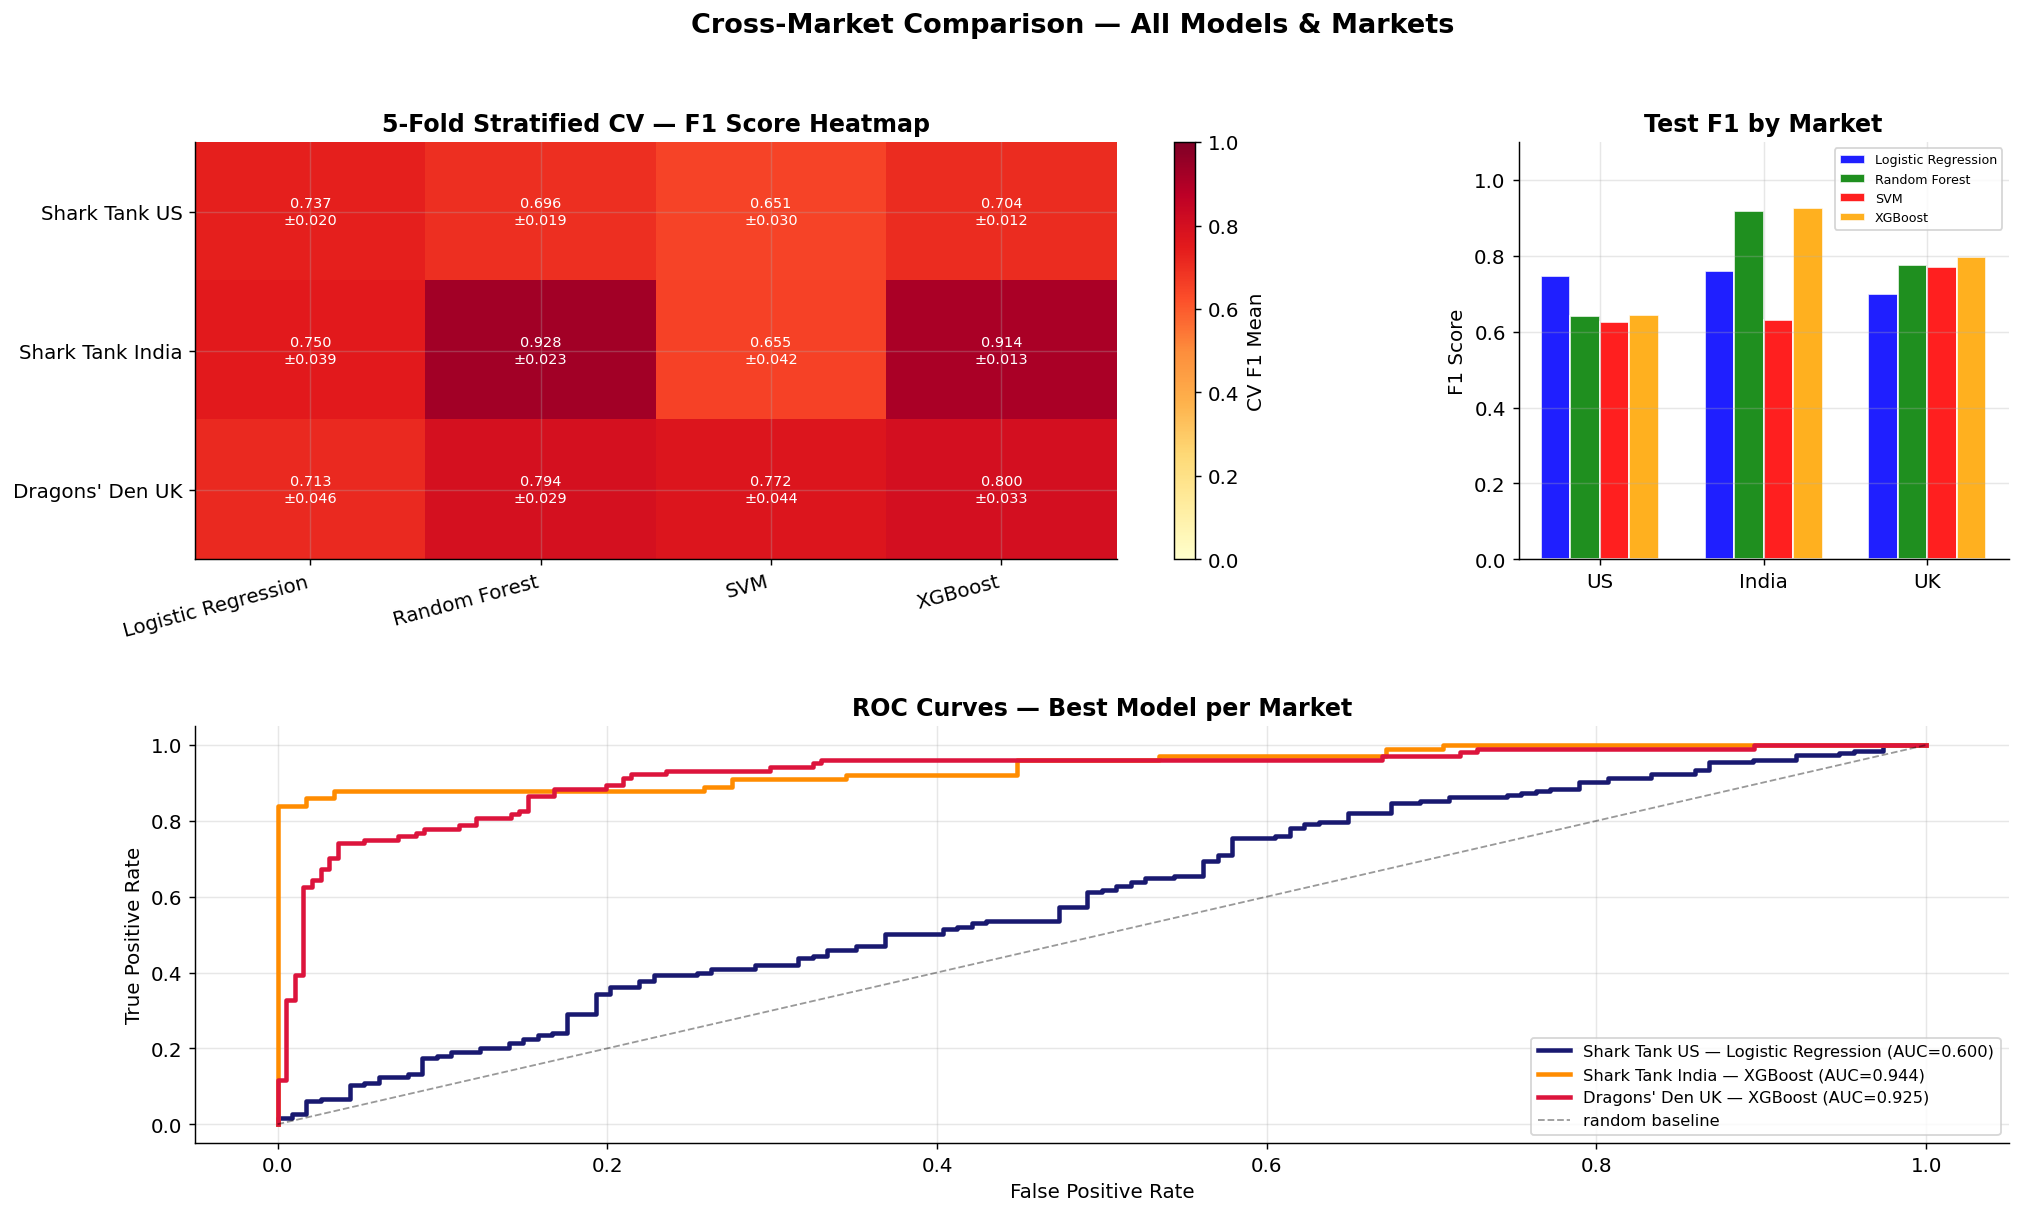

In [26]:
# cross-market comparison
model_names  = ['Logistic Regression','Random Forest','SVM','XGBoost']
market_names = ['US','India','UK']

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Cross-Market Comparison — All Models & Markets',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# cv f1 heatmap
ax_heat = fig.add_subplot(gs[0, :2])
cv_mat = np.array([[market_results[mkt][mdl]['CV_F1_mean'] for mdl in model_names]
                   for mkt in market_names])
im = ax_heat.imshow(cv_mat, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax_heat.set_xticks(range(4)); ax_heat.set_xticklabels(model_names, rotation=15, ha='right')
ax_heat.set_yticks(range(3)); ax_heat.set_yticklabels([market_labels[m] for m in market_names])
plt.colorbar(im, ax=ax_heat, label='CV F1 Mean')
ax_heat.set_title(f'{CV_FOLDS}-Fold Stratified CV — F1 Score Heatmap', fontweight='bold')
for i in range(3):
    for j in range(4):
        v   = cv_mat[i,j]; s = market_results[market_names[i]][model_names[j]]['CV_F1_std']
        col = 'white' if v > 0.6 else 'black'
        ax_heat.text(j, i, f'{v:.3f}\n±{s:.3f}', ha='center', va='center',
                     color=col, fontsize=8)

# best f1 per market grouped bar
ax_bar = fig.add_subplot(gs[0, 2])
x = np.arange(3); w = 0.18
for i, (mname, mc) in enumerate(PALETTE.items()):
    f1s = [market_results[mkt][mname]['F1'] for mkt in market_names]
    ax_bar.bar(x + (i-1.5)*w, f1s, w, label=mname, color=mc, alpha=0.88, edgecolor='white')
ax_bar.set_xticks(x); ax_bar.set_xticklabels(['US','India','UK'])
ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel('F1 Score')
ax_bar.set_title('Test F1 by Market', fontweight='bold')
ax_bar.legend(fontsize=7, loc='upper right')

# ROC - best model per market
ax_roc = fig.add_subplot(gs[1, :])
for market in ['US','India','UK']:
    best = best_model_per_market[market]
    m    = market_results[market][best]
    try:
        fpr, tpr, _ = roc_curve(m['y_test'], m['y_proba'])
        ax_roc.plot(fpr, tpr, color=MARKET_COLORS[market], lw=2.5,
                    label=f"{market_labels[market]} — {best} (AUC={m['ROC-AUC']:.3f})")
    except Exception:
        pass
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='random baseline')
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — Best Model per Market', fontweight='bold')
ax_roc.legend(fontsize=9, loc='lower right')

plt.savefig('fig_cross_market_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Doing Statistical Significance — paired t-Test
# A **paired t-test** compares two models using their CV fold scores across the same folds.
# If p < 0.05, the difference in performance is statistically significant and not due to chance.

# paired t-test: best model vs all others per market
ttest_rows = []
for market in ['US','India','UK']:
    mres = market_results[market]
    best = best_model_per_market[market]
    best_scores = mres[best]['CV_fold_scores']

    print(f"\n{market_labels[market]}  (best model: {best})")
    print(f"{'Compared Against':<25} {'t-stat':>8} {'p-value':>10}  {'Significant':>12}")
    print(f"{'-'*60}")

    for mname, m in mres.items():
        if mname == best:
            continue
        other_scores = m['CV_fold_scores']
        valid = ~(np.isnan(best_scores) | np.isnan(other_scores))
        if valid.sum() < 2:
            t_stat, p_val = float('nan'), float('nan')
        else:
            t_stat, p_val = stats.ttest_rel(best_scores[valid], other_scores[valid])
        sig = 'YES ***' if (not np.isnan(p_val) and p_val < 0.05) else 'No'
        print(f"{mname:<25} {t_stat:>8.3f} {p_val:>10.4f}  {sig:>12}")
        ttest_rows.append({'Market':market,'Best':best,'Compared Against':mname,
                           't-stat':round(t_stat,4),'p-value':round(p_val,4),
                           'Significant': p_val < 0.05 if not np.isnan(p_val) else False})

ttest_df = pd.DataFrame(ttest_rows)


Shark Tank US  (best model: Logistic Regression)
Compared Against            t-stat    p-value   Significant
------------------------------------------------------------
Random Forest                3.480     0.0254       YES ***
SVM                          7.093     0.0021       YES ***
XGBoost                      4.303     0.0126       YES ***

Shark Tank India  (best model: XGBoost)
Compared Against            t-stat    p-value   Significant
------------------------------------------------------------
Logistic Regression          8.071     0.0013       YES ***
Random Forest               -1.667     0.1709            No
SVM                         14.683     0.0001       YES ***

Dragons' Den UK  (best model: XGBoost)
Compared Against            t-stat    p-value   Significant
------------------------------------------------------------
Logistic Regression          4.345     0.0122       YES ***
Random Forest                0.624     0.5662            No
SVM                       

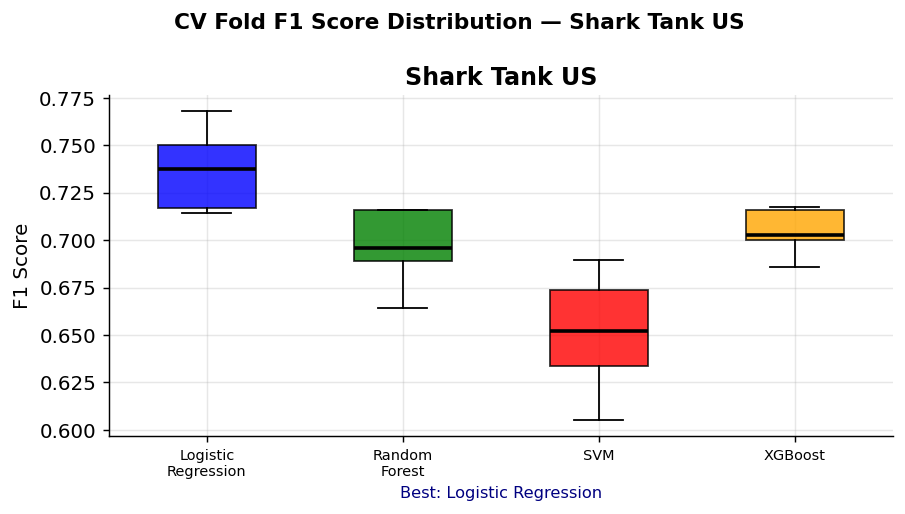

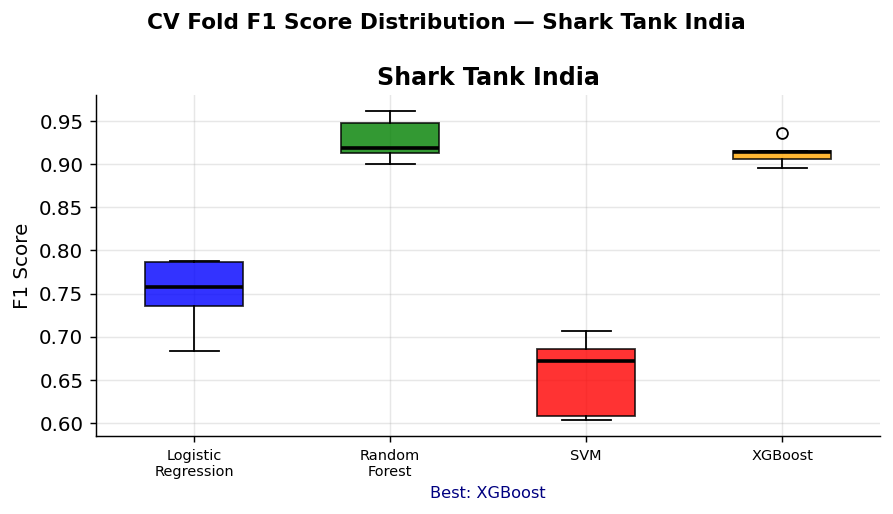

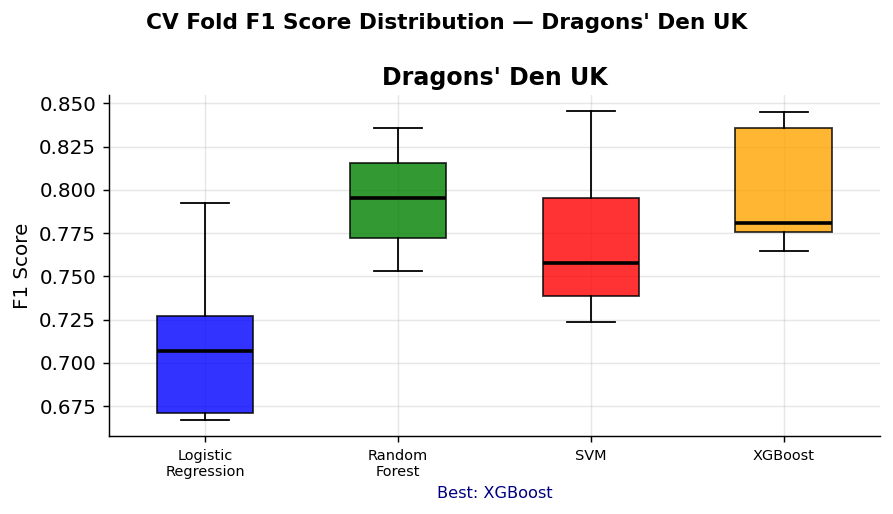

In [28]:

# CV fold distributions - one plot per market
for market in ['US','India','UK']:
    mres  = market_results[market]
    data  = []
    names = []
    for mname in PALETTE:
        scores = mres[mname]['CV_fold_scores']
        valid  = scores[~np.isnan(scores)]
        if len(valid):
            data.append(valid)
            names.append(mname)

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.suptitle(f'CV Fold F1 Score Distribution — {market_labels[market]}',
                 fontsize=12, fontweight='bold')
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
    for patch, mname in zip(bp['boxes'], names):
        patch.set_facecolor(PALETTE[mname])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(names)+1))
    ax.set_xticklabels([n.replace(' ','\n') for n in names], fontsize=8)
    ax.set_title(market_labels[market], fontweight='bold')
    ax.set_ylabel('F1 Score')
    best = best_model_per_market[market]
    ax.set_xlabel(f'Best: {best}', fontsize=9, color='navy')
    plt.tight_layout()
    plt.savefig(f'fig_ttest_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [29]:
# Cross-Market Transfer Experiment
# Can a model trained on two markets generalise to the third?

# Three transfer configurations:
# Train: US + India → Test: UK
# Train: US + UK → Test: India
# Train: India + UK → Test: US

from sklearn.utils import resample

def run_transfer(train_markets, test_market, model_name='Random Forest'):
    # train on combined markets, test on held-out market
    Xs, ys = [], []
    for m in train_markets:
        X_arr = market_data[m][0].values
        y_arr = market_data[m][1].values
        Xs.append((market_data[m][0], market_data[m][1]))
        ys.append(y_arr)

    col_sets = [set(market_data[m][0].columns) for m in train_markets]
    col_sets.append(set(market_data[test_market][0].columns))
    shared_cols = list(col_sets[0].intersection(*col_sets[1:]))

    if len(shared_cols) == 0:
        return None

    X_train_all = pd.concat(
        [market_data[m][0][shared_cols] for m in train_markets]
    ).values
    y_train_all = np.concatenate([market_data[m][1].values for m in train_markets])
    X_test_all  = market_data[test_market][0][shared_cols].values
    y_test_all  = market_data[test_market][1].values

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_train_all)
    X_te   = scaler.transform(X_test_all)

    if model_name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                       random_state=RANDOM_STATE)
    elif model_name == 'XGBoost':
        model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                  eval_metric='logloss',
                                  random_state=RANDOM_STATE, verbosity=0)
    elif model_name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    else:
        model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

    model.fit(X_tr, y_train_all)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    return {
        'F1':       f1_score(y_test_all, y_pred, zero_division=0),
        'ROC-AUC':  roc_auc_score(y_test_all, y_proba) if len(np.unique(y_test_all)) > 1 else float('nan'),
        'Accuracy': accuracy_score(y_test_all, y_pred),
        'Shared_Features': len(shared_cols),
    }

market_data = {'US':(X_us,y_us), 'India':(X_india,y_india), 'UK':(X_uk,y_uk)}

configs = [
    (['US','India'], 'UK'),
    (['US','UK'],    'India'),
    (['India','UK'], 'US'),
]

trans_rows = []
print("CROSS-MARKET TRANSFER RESULTS")
print(f"\n  {'Train On':<20} {'Test On':<15} {'Shared Feats':>12} {'F1':>8} {'AUC':>8}")
print(f"{'-'*65}")

for train_mkts, test_mkt in configs:
    for mname in ['Random Forest','XGBoost','Logistic Regression']:
        res = run_transfer(train_mkts, test_mkt, mname)
        if res is None:
            print(f"{'+'.join(train_mkts):<20} {test_mkt:<15}  no shared features")
            continue
        baseline_f1 = market_results[test_mkt][mname]['F1']
        diff = res['F1'] - baseline_f1
        sign = '+' if diff >= 0 else ''
        print(f"{'+'.join(train_mkts):<20} {test_mkt:<15} {res['Shared_Features']:>12}"
              f" {res['F1']:>8.4f} {res['ROC-AUC']:>8.4f}"
              f"(vs in-market baseline {baseline_f1:.4f}, delta {sign}{diff:.4f})")
        trans_rows.append({
            'Train': '+'.join(train_mkts), 'Test': test_mkt, 'Model': mname,
            'Transfer_F1': round(res['F1'],4), 'Transfer_AUC': round(res['ROC-AUC'],4),
            'Baseline_F1': round(baseline_f1,4),
            'F1_Delta': round(diff,4),
            'Shared_Features': res['Shared_Features'],
        })

transfer_df = pd.DataFrame(trans_rows)

CROSS-MARKET TRANSFER RESULTS

  Train On             Test On         Shared Feats       F1      AUC
-----------------------------------------------------------------
US+India             UK                        13   0.5225   0.5978(vs in-market baseline 0.7772, delta -0.2547)
US+India             UK                        13   0.5259   0.6739(vs in-market baseline 0.7960, delta -0.2702)
US+India             UK                        13   0.4087   0.4396(vs in-market baseline 0.6995, delta -0.2908)
US+UK                India                     13   0.1687   0.5276(vs in-market baseline 0.9189, delta -0.7502)
US+UK                India                     13   0.1312   0.4324(vs in-market baseline 0.9263, delta -0.7951)
US+UK                India                     13   0.2118   0.4151(vs in-market baseline 0.7596, delta -0.5479)
India+UK             US                        13   0.2055   0.5392(vs in-market baseline 0.6406, delta -0.4351)
India+UK             US                   

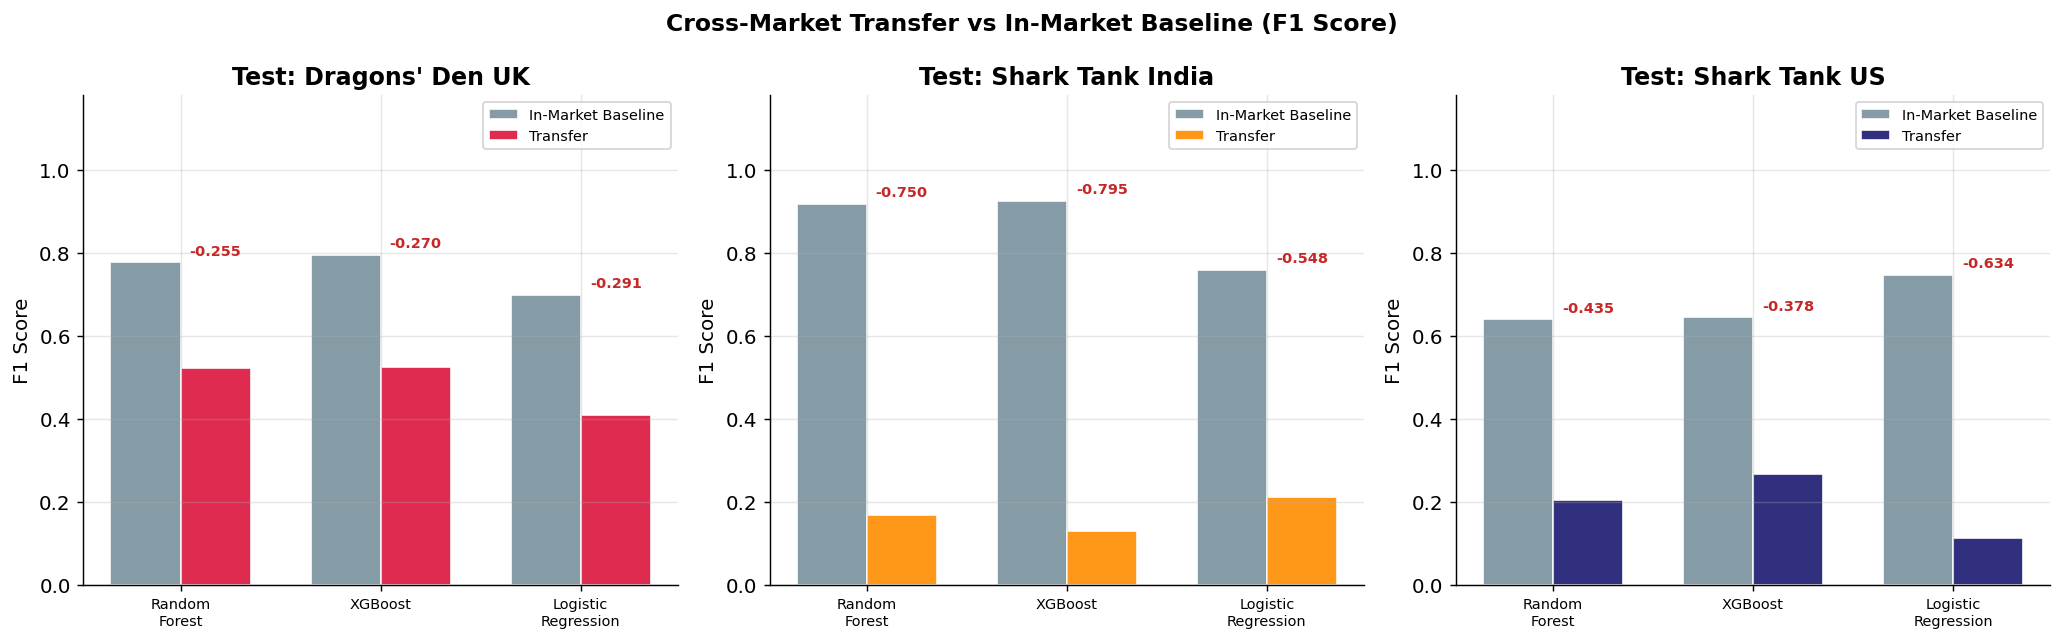

positive delta = transfer model beats in-market baseline


In [30]:

# Transfer Experiment visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cross-Market Transfer vs In-Market Baseline (F1 Score)',
             fontsize=13, fontweight='bold')

test_markets = ['UK','India','US']
for ax, test_mkt in zip(axes, test_markets):
    sub    = transfer_df[transfer_df['Test'] == test_mkt]
    if len(sub) == 0:
        ax.text(0.5,0.5,'No shared features',ha='center',va='center',transform=ax.transAxes)
        ax.set_title(market_labels[test_mkt], fontweight='bold'); continue
    models = sub['Model'].tolist()
    x      = np.arange(len(models)); w = 0.35
    bars1  = ax.bar(x - w/2, sub['Baseline_F1'], w, label='In-Market Baseline',
                    color='#78909C', edgecolor='white', alpha=0.9)
    bars2  = ax.bar(x + w/2, sub['Transfer_F1'], w, label='Transfer',
                    color=MARKET_COLORS[test_mkt], edgecolor='white', alpha=0.9)
    for b1, b2 in zip(bars1, bars2):
        d = b2.get_height() - b1.get_height()
        c = '#388E3C' if d > 0 else '#C62828'
        ax.text(b2.get_x()+b2.get_width()/2,
                max(b1.get_height(), b2.get_height())+0.01,
                f'{d:+.3f}', ha='center', va='bottom', fontsize=8,
                color=c, fontweight='bold')
    ax.set_title(f'Test: {market_labels[test_mkt]}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
    ax.set_ylim(0, 1.18); ax.set_ylabel('F1 Score')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_transfer_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("positive delta = transfer model beats in-market baseline")

In [31]:
# Optimal Decision Threshold Tuning
# Default ML threshold = 0.5. optimal threshold = maximises F1 on the test set. Because this is especially important under class imbalance.


# threshold tuning results
thr_rows = []
print("THRESHOLD TUNING RESULTS")
print(f"\n  {'Market':<10} {'Model':<22} {'Default F1':>10} {'Opt Thresh':>10} {'Opt F1':>10} {'Gain':>8}")
print(f"{'-'*70}")

for market in ['US','India','UK']:
    for mname, m in market_results[market].items():
        f1_def = m['F1']
        f1_opt = m['F1_at_OptThresh']
        thr    = m['Opt_Threshold']
        gain   = f1_opt - f1_def
        sign   = '+' if gain >= 0 else ''
        print(f"{market:<10} {mname:<22} {f1_def:>10.4f} {thr:>10.3f} {f1_opt:>10.4f} {sign}{gain:>7.4f}")
        thr_rows.append({'Market':market,'Model':mname,
                         'F1_Default':round(f1_def,4),
                         'Optimal_Threshold':round(thr,3),
                         'F1_Optimal':round(f1_opt,4),
                         'F1_Gain':round(gain,4)})

threshold_df = pd.DataFrame(thr_rows)

THRESHOLD TUNING RESULTS

  Market     Model                  Default F1 Opt Thresh     Opt F1     Gain
----------------------------------------------------------------------
US         Logistic Regression        0.7471      0.316     0.7673 + 0.0202
US         Random Forest              0.6406      0.165     0.7625 + 0.1219
US         SVM                        0.6250      0.454     0.7657 + 0.1407
US         XGBoost                    0.6447      0.244     0.7637 + 0.1190
India      Logistic Regression        0.7596      0.366     0.7945 + 0.0349
India      Random Forest              0.9189      0.465     0.9198 + 0.0009
India      SVM                        0.6303      0.415     0.8083 + 0.1780
India      XGBoost                    0.9263      0.522     0.9263 + 0.0000
UK         Logistic Regression        0.6995      0.291     0.7453 + 0.0458
UK         Random Forest              0.7772      0.305     0.8035 + 0.0263
UK         SVM                        0.7714      0.309     0.790

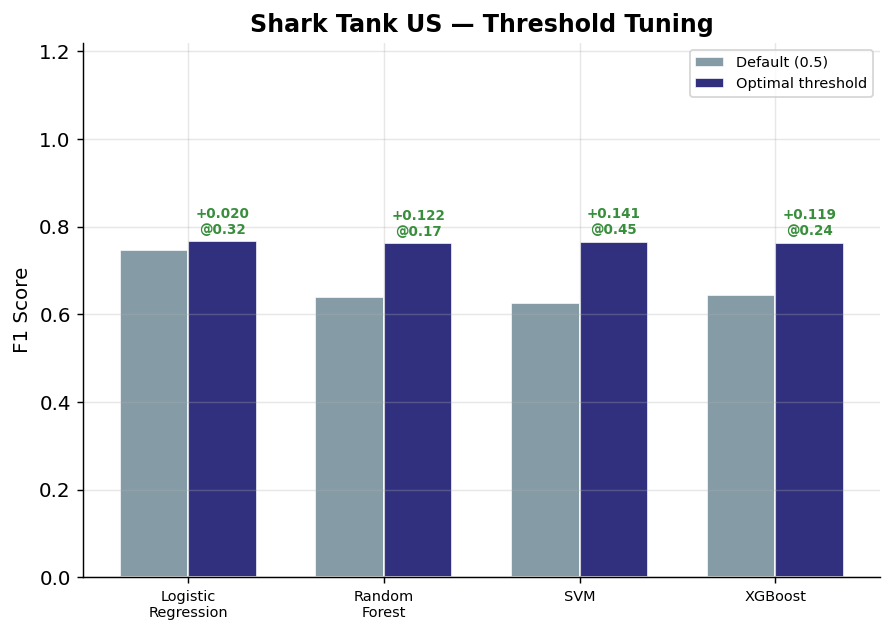

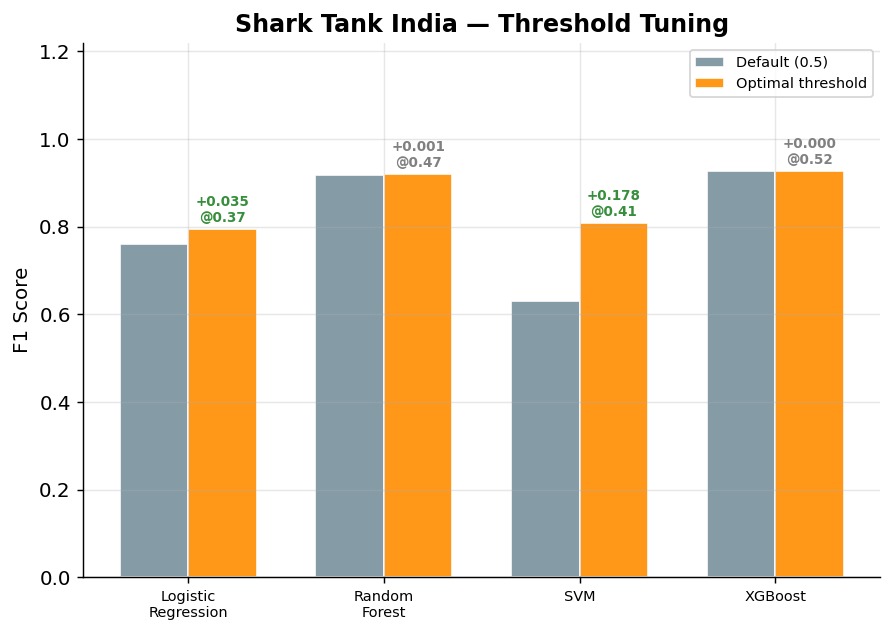

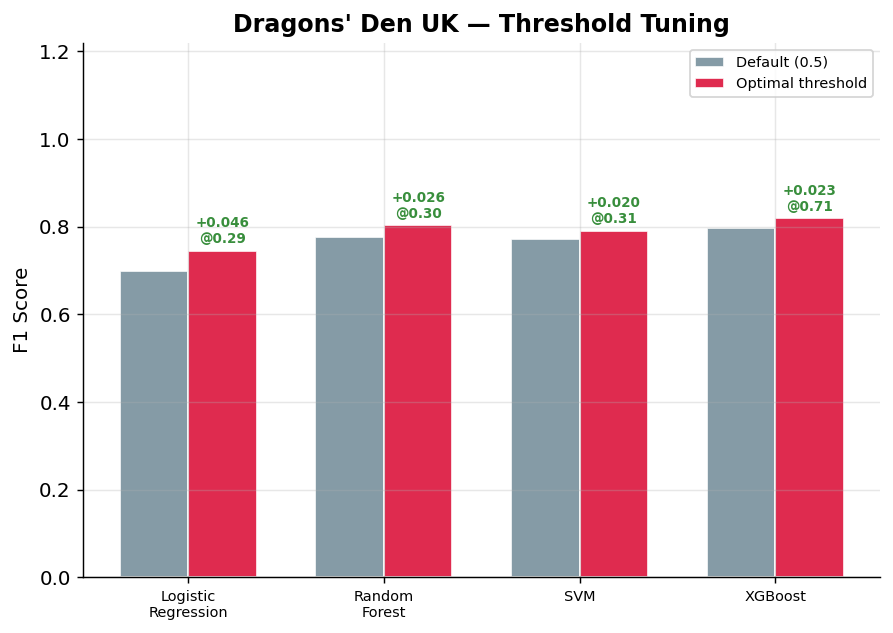

In [32]:
# threshold tuning - one plot per market
for market in ['US','India','UK']:
    sub = threshold_df[threshold_df['Market'] == market]
    fig, ax = plt.subplots(figsize=(7, 5))
    x   = np.arange(len(sub)); w = 0.35
    b1  = ax.bar(x - w/2, sub['F1_Default'], w, label='Default (0.5)',
                 color='#78909C', edgecolor='white', alpha=0.9)
    b2  = ax.bar(x + w/2, sub['F1_Optimal'], w, label='Optimal threshold',
                 color=MARKET_COLORS[market], edgecolor='white', alpha=0.9)
    for bar1, bar2, thr in zip(b1, b2, sub['Optimal_Threshold']):
        gain = bar2.get_height() - bar1.get_height()
        col  = '#388E3C' if gain > 0.005 else ('#C62828' if gain < -0.005 else 'gray')
        ax.text(bar2.get_x()+bar2.get_width()/2,
                max(bar1.get_height(), bar2.get_height())+0.01,
                f'+{gain:.3f}\n@{thr:.2f}', ha='center', va='bottom',
                fontsize=7.5, color=col, fontweight='bold')
    ax.set_title(f'{market_labels[market]} — Threshold Tuning', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in sub['Model']], fontsize=8)
    ax.set_ylim(0, 1.22); ax.set_ylabel('F1 Score')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fig_threshold_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

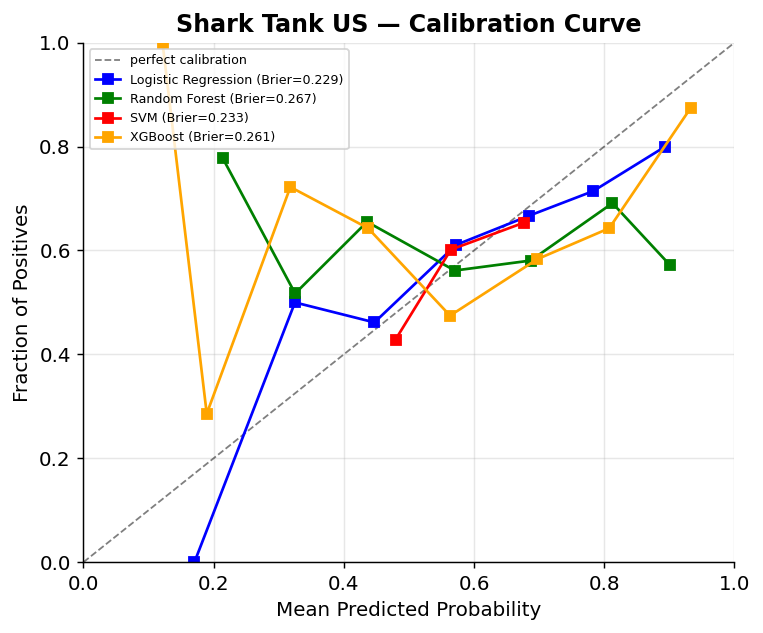

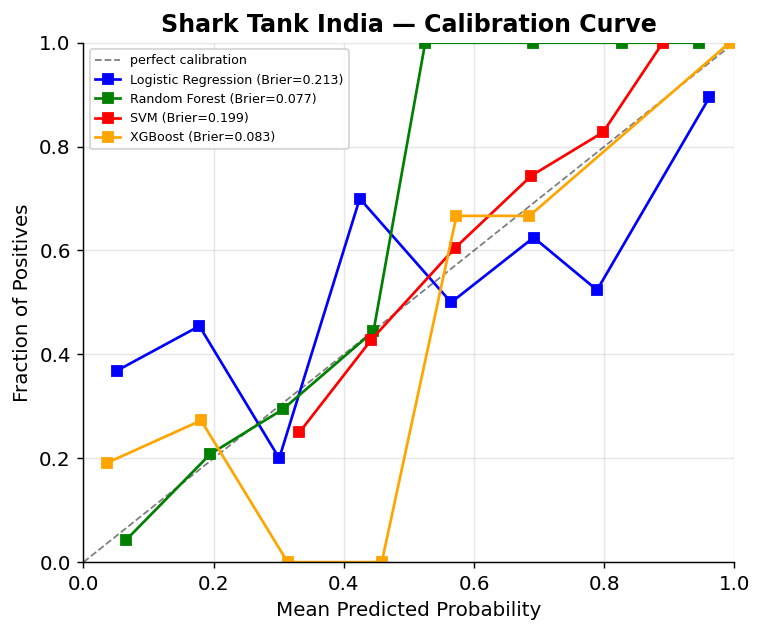

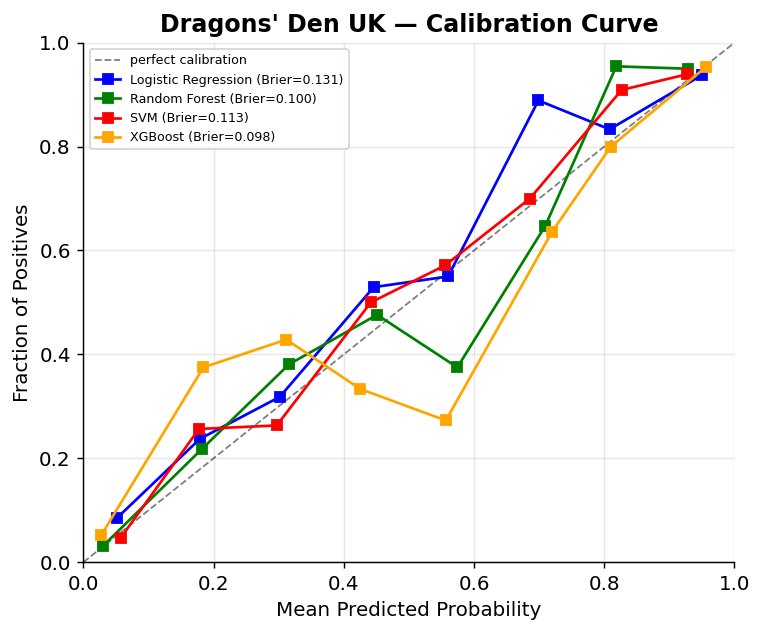


Brier Scores (lower = better, 0.25 = random baseline):
Market               Model  Brier_Score
    US Logistic Regression       0.2289
    US       Random Forest       0.2672
    US                 SVM       0.2332
    US             XGBoost       0.2607
 India Logistic Regression       0.2134
 India       Random Forest       0.0766
 India                 SVM       0.1993
 India             XGBoost       0.0834
    UK Logistic Regression       0.1314
    UK       Random Forest       0.1000
    UK                 SVM       0.1125
    UK             XGBoost       0.0976


In [33]:
# Model Calibration Analysis
# A well-calibrated model means: when it says 70% probability of a deal, 70% of those pitches actually get deals.
# Brier Score = lower is better (0 = perfect, 0.25 = no-skill baseline).

calib_rows = []

for market in ['US','India','UK']:
    mres = market_results[market]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='perfect calibration')
    for mname, mc in PALETTE.items():
        m = mres[mname]
        try:
            frac_pos, mean_pred = calibration_curve(
                m['y_test'], m['y_proba'], n_bins=8, strategy='uniform')
            bs = m['Brier_Score']
            ax.plot(mean_pred, frac_pos, 's-', color=mc, lw=1.5, ms=5,
                    label=f'{mname} (Brier={bs:.3f})')
            calib_rows.append({'Market':market,'Model':mname,
                                'Brier_Score':round(bs,4)})
        except Exception:
            pass
    ax.set_title(f'{market_labels[market]} — Calibration Curve', fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=7, loc='upper left')
    plt.tight_layout()
    plt.savefig(f'fig_calibration_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

calib_df = pd.DataFrame(calib_rows)
print("\nBrier Scores (lower = better, 0.25 = random baseline):")
print(calib_df.to_string(index=False))

In [34]:
# Class Imbalance — SMOTE vs Baseline

# smote comparison - train with and without smote
smote_rows = []
print("training with and without smote for all markets...")

for market, (X, y) in market_data.items():
    res_no    = train_all_models(X, y, market_labels[market], use_smote=False, verbose=False)
    res_smote = train_all_models(X, y, market_labels[market], use_smote=True,  verbose=False)
    for mname in res_no:
        f1_b = res_no[mname]['F1'];  f1_s = res_smote[mname]['F1']
        smote_rows.append({'Market':market,'Model':mname,
                           'F1 (No SMOTE)':round(f1_b,4),
                           'F1 (SMOTE)':round(f1_s,4),
                           'F1 Delta':round(f1_s-f1_b,4)})

smote_df = pd.DataFrame(smote_rows)
print(smote_df.to_string(index=False))

training with and without smote for all markets...
Market               Model  F1 (No SMOTE)  F1 (SMOTE)  F1 Delta
    US Logistic Regression         0.7471      0.6079   -0.1392
    US       Random Forest         0.6406      0.6347   -0.0060
    US                 SVM         0.6250      0.6558    0.0308
    US             XGBoost         0.6447      0.6526    0.0080
 India Logistic Regression         0.7596      0.7576   -0.0020
 India       Random Forest         0.9189      0.9140   -0.0049
 India                 SVM         0.6303      0.6857    0.0554
 India             XGBoost         0.9263      0.9198   -0.0065
    UK Logistic Regression         0.6995      0.7264    0.0269
    UK       Random Forest         0.7772      0.7839    0.0067
    UK                 SVM         0.7714      0.7624   -0.0091
    UK             XGBoost         0.7960      0.7961    0.0001


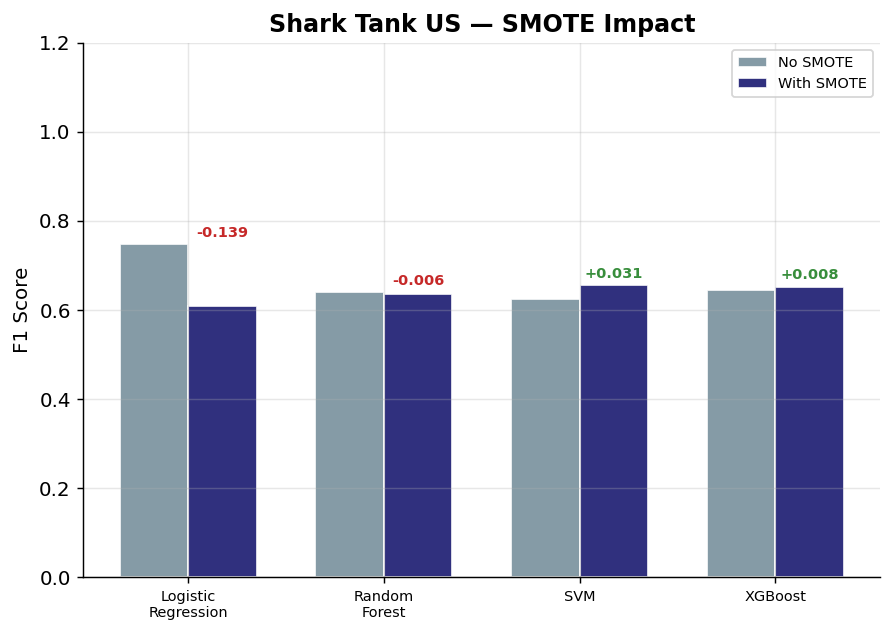

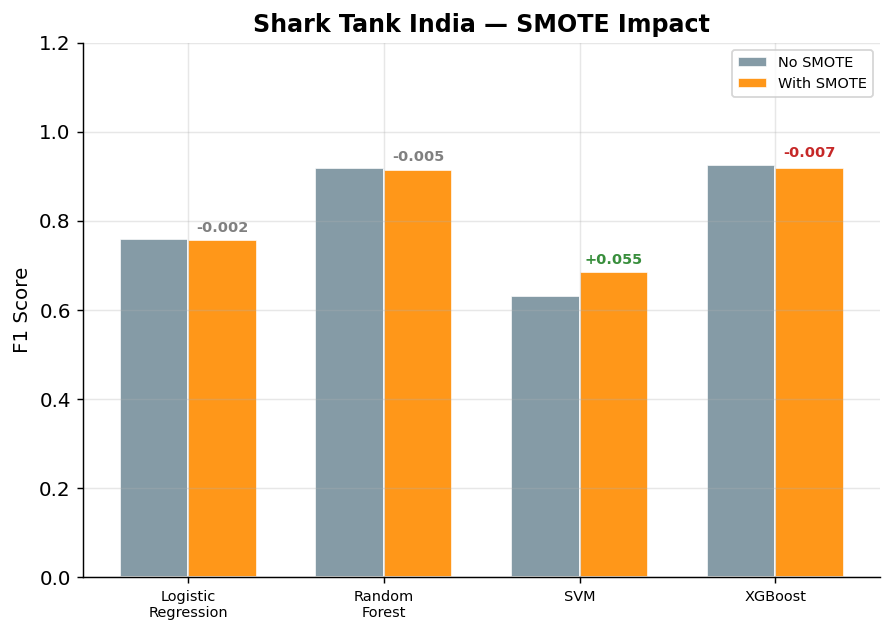

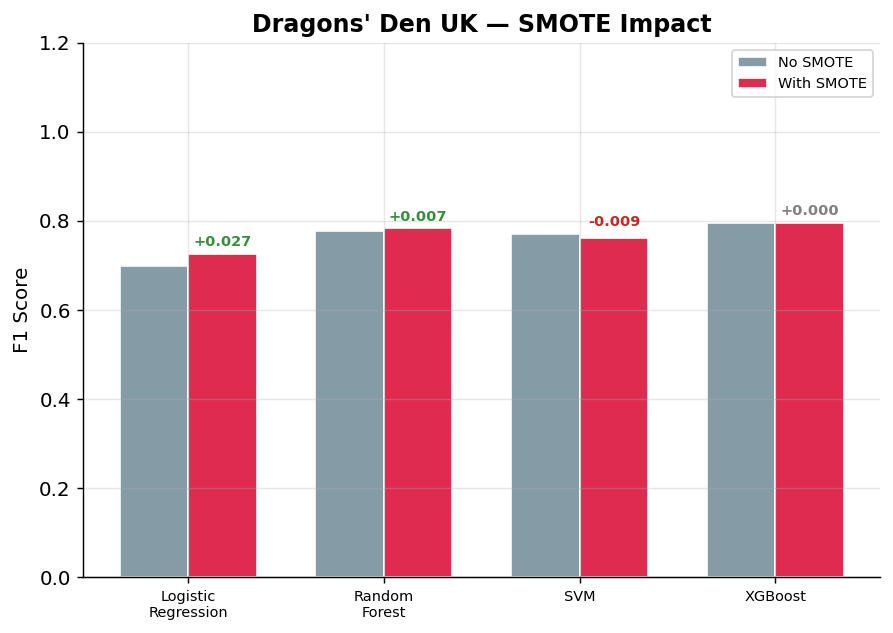

In [35]:

# SMOTE Impact

for market in ['US','India','UK']:
    sub = smote_df[smote_df['Market'] == market]
    fig, ax = plt.subplots(figsize=(7, 5))
    x   = np.arange(len(sub)); w = 0.35
    b1  = ax.bar(x-w/2, sub['F1 (No SMOTE)'], w, label='No SMOTE',
                 color='#78909C', edgecolor='white', alpha=0.9)
    b2  = ax.bar(x+w/2, sub['F1 (SMOTE)'], w, label='With SMOTE',
                 color=MARKET_COLORS[market], edgecolor='white', alpha=0.9)
    for bar1, bar2 in zip(b1, b2):
        d   = bar2.get_height() - bar1.get_height()
        col = '#388E3C' if d > 0.005 else ('#C62828' if d < -0.005 else 'gray')
        ax.text(bar2.get_x()+bar2.get_width()/2,
                max(bar1.get_height(),bar2.get_height())+0.01,
                f'{d:+.3f}', ha='center', va='bottom', fontsize=8,
                color=col, fontweight='bold')
    ax.set_title(f'{market_labels[market]} — SMOTE Impact', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in sub['Model']], fontsize=8)
    ax.set_ylim(0,1.2); ax.set_ylabel('F1 Score'); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fig_smote_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [36]:
# per 100 pitches
print("OPERATIONAL IMPACT ANALYSIS") # Translating model metrics into real-world value for entrepreneurs and investors.

print("scenario: entrepreneur uses model to predict pitch success before entering the tank")
print()

imp_rows = []

for market in ['US','India','UK']:
    best_name = best_model_per_market[market]
    m         = market_results[market][best_name]
    y_test    = m['y_test']
    y_proba   = m['y_proba']

    opt_thr   = m['Opt_Threshold']
    y_pred_opt= m['y_pred_opt']

    n_test    = len(y_test)
    n_deals   = y_test.sum()
    deal_rate = n_deals / n_test

    tp = int(((y_pred_opt == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_opt == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_opt == 0) & (y_test == 1)).sum())
    tn = int(((y_pred_opt == 0) & (y_test == 0)).sum())

    scale    = 100 / n_test
    tp100    = round(tp * scale, 1)
    fp100    = round(fp * scale, 1)
    fn100    = round(fn * scale, 1)
    tn100    = round(tn * scale, 1)
    deals100 = round(deal_rate * 100, 1)

    random_tp100 = round(deal_rate * deal_rate * 100, 1)
    extra_caught = round(tp100 - random_tp100, 1)
    prec = precision_score(y_test, y_pred_opt, zero_division=0)
    rec  = recall_score(y_test, y_pred_opt, zero_division=0)

    print(f"{market_labels[market]}  [{best_name}]")
    print(f"test set size          : {n_test} pitches")
    print(f"natural deal rate      : {deal_rate*100:.1f}% ({deals100:.1f} deals per 100 pitches)")
    print(f"threshold used         : {opt_thr:.3f}")
    print(f"per 100 pitches:")
    print(f"correctly predicted deal : {tp100:>5.1f}  (true positives)")
    print(f"false alarms             : {fp100:>5.1f}  (false positives)")
    print(f"missed deals             : {fn100:>5.1f}  (false negatives)")
    print(f"correctly rejected       : {tn100:>5.1f}  (true negatives)")
    print(f"extra deals vs random  : +{extra_caught:.1f} per 100 pitches")
    print(f"precision              : {prec:.1%}")
    print(f"recall                 : {rec:.1%}")
    print()

    imp_rows.append({
        'Market':        market_labels[market],
        'Best Model':    best_name,
        'Natural Deal %':f'{deal_rate*100:.1f}%',
        'Opt Threshold': round(opt_thr, 3),
        'TP per 100':    tp100,
        'FP per 100':    fp100,
        'Extra vs Random': extra_caught,
        'Precision':     f'{prec:.1%}',
        'Recall':        f'{rec:.1%}',
    })

impact_df = pd.DataFrame(imp_rows)

OPERATIONAL IMPACT ANALYSIS
scenario: entrepreneur uses model to predict pitch success before entering the tank

Shark Tank US  [Logistic Regression]
test set size          : 297 pitches
natural deal rate      : 61.6% (61.6 deals per 100 pitches)
threshold used         : 0.316
per 100 pitches:
correctly predicted deal :  61.6  (true positives)
false alarms             :  37.4  (false positives)
missed deals             :   0.0  (false negatives)
correctly rejected       :   1.0  (true negatives)
extra deals vs random  : +23.6 per 100 pitches
precision              : 62.2%
recall                 : 100.0%

Shark Tank India  [XGBoost]
test set size          : 158 pitches
natural deal rate      : 63.3% (63.3 deals per 100 pitches)
threshold used         : 0.522
per 100 pitches:
correctly predicted deal :  55.7  (true positives)
false alarms             :   1.3  (false positives)
missed deals             :   7.6  (false negatives)
correctly rejected       :  35.4  (true negatives)
extra dea

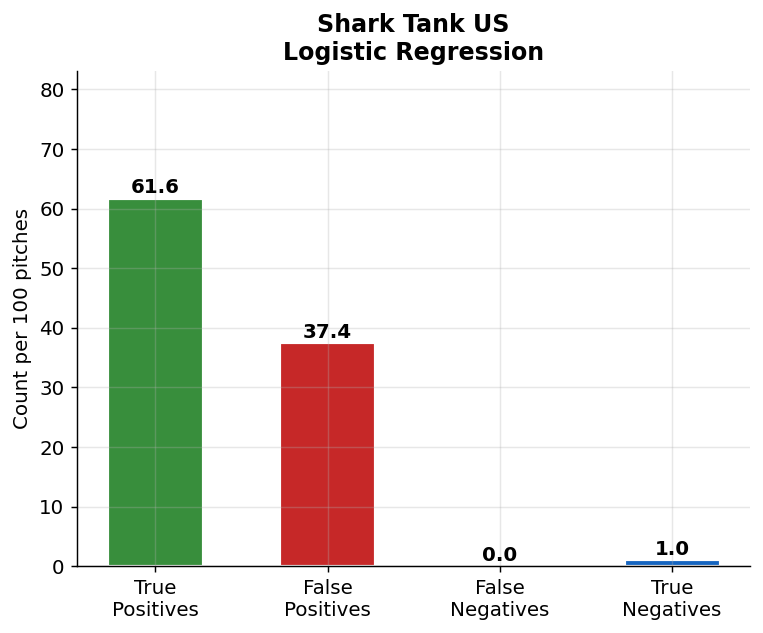

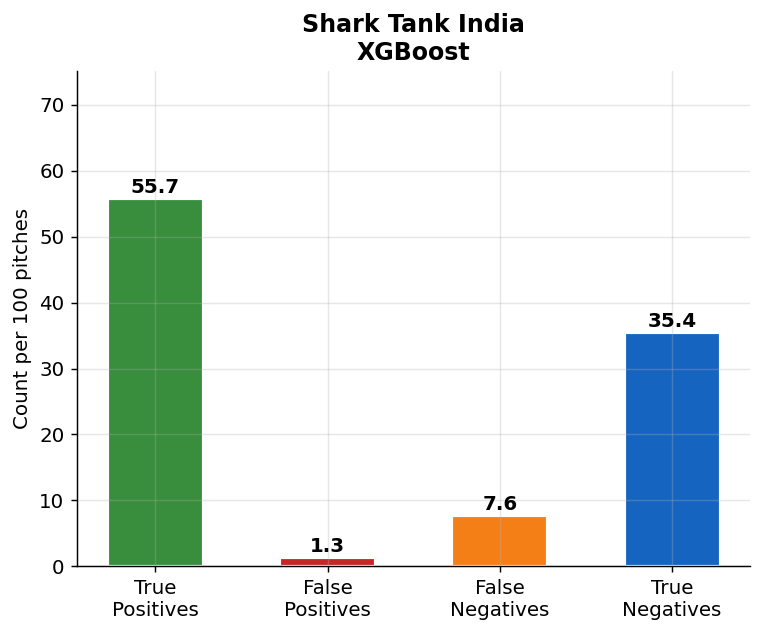

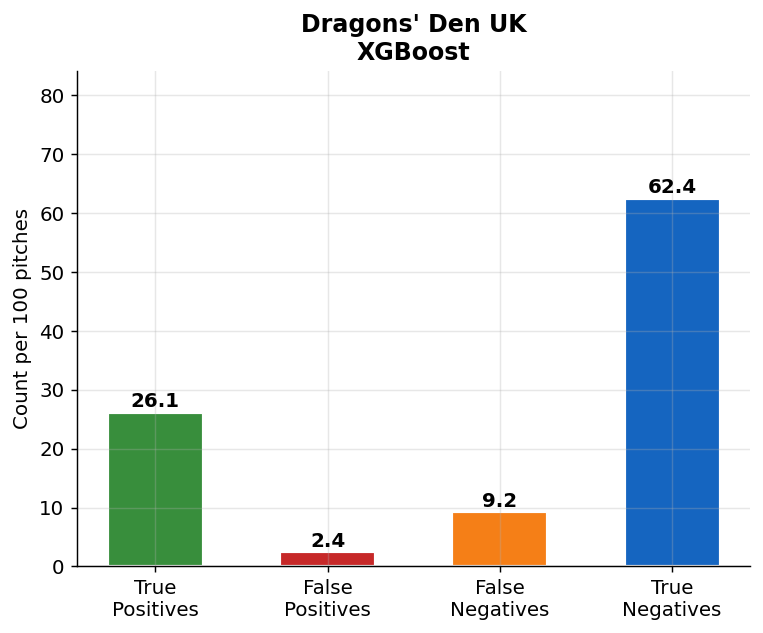

In [37]:
# operational impact - 
for market in ['US','India','UK']:
    best_name = best_model_per_market[market]
    m         = market_results[market][best_name]
    y_test    = m['y_test']
    y_pred_opt= m['y_pred_opt']
    n_test    = len(y_test)
    scale     = 100 / n_test

    tp100 = round(((y_pred_opt==1)&(y_test==1)).sum() * scale, 1)
    fp100 = round(((y_pred_opt==1)&(y_test==0)).sum() * scale, 1)
    fn100 = round(((y_pred_opt==0)&(y_test==1)).sum() * scale, 1)
    tn100 = round(((y_pred_opt==0)&(y_test==0)).sum() * scale, 1)

    categories = ['True\nPositives','False\nPositives','False\nNegatives','True\nNegatives']
    values     = [tp100, fp100, fn100, tn100]
    colors_op  = ['#388E3C','#C62828','#F57F17','#1565C0']

    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(categories, values, color=colors_op, edgecolor='white',
                  linewidth=1.2, width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{market_labels[market]}\n{best_name}', fontweight='bold')
    ax.set_ylabel('Count per 100 pitches')
    ax.set_ylim(0, max(values)*1.35)
    plt.tight_layout()
    plt.savefig(f'fig_operational_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

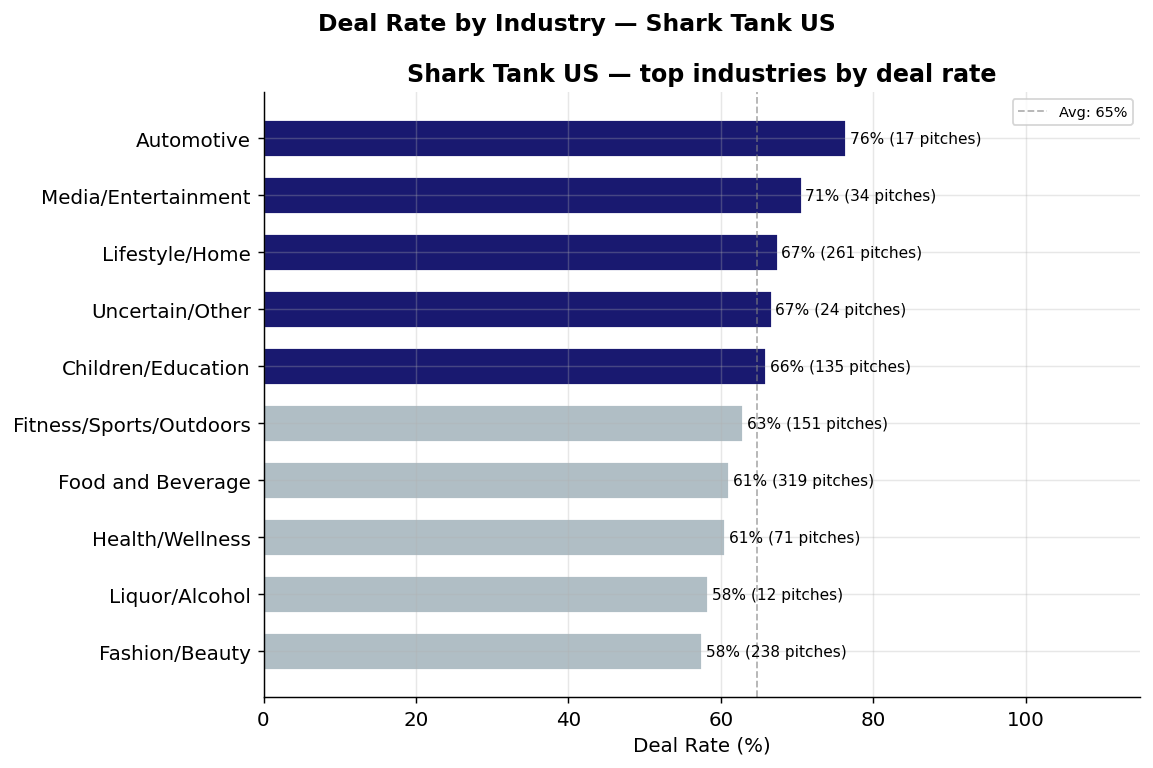

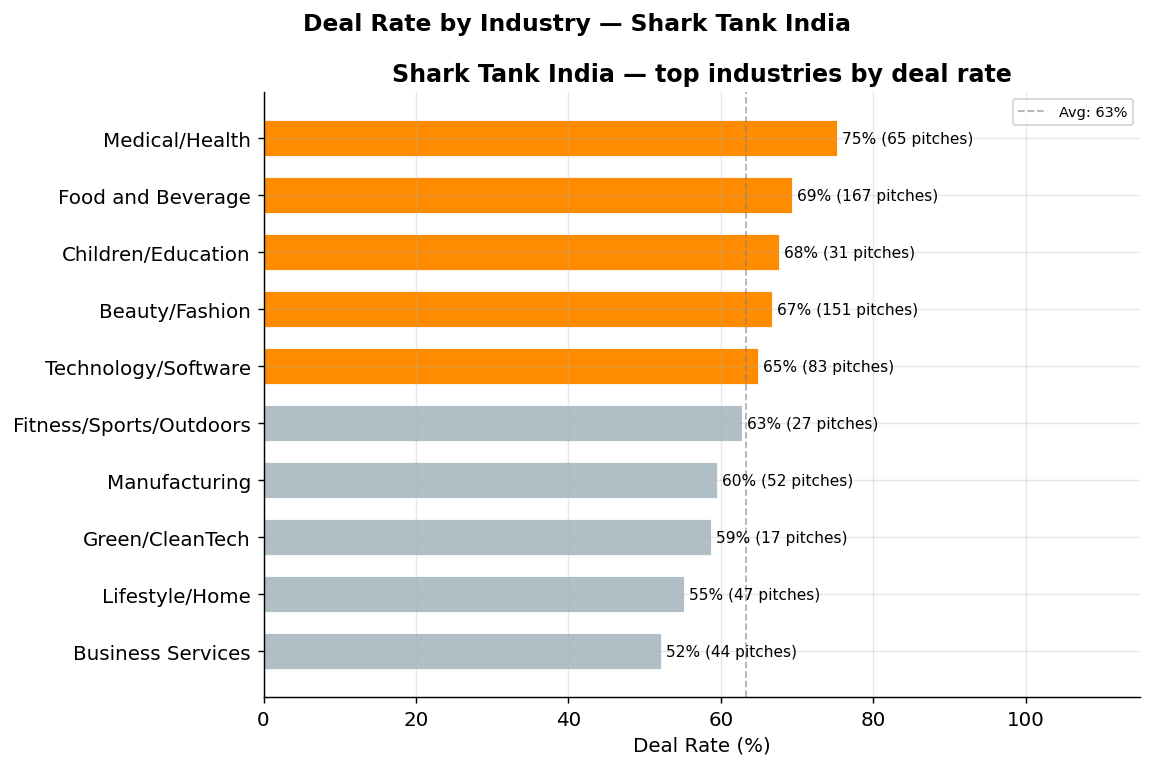

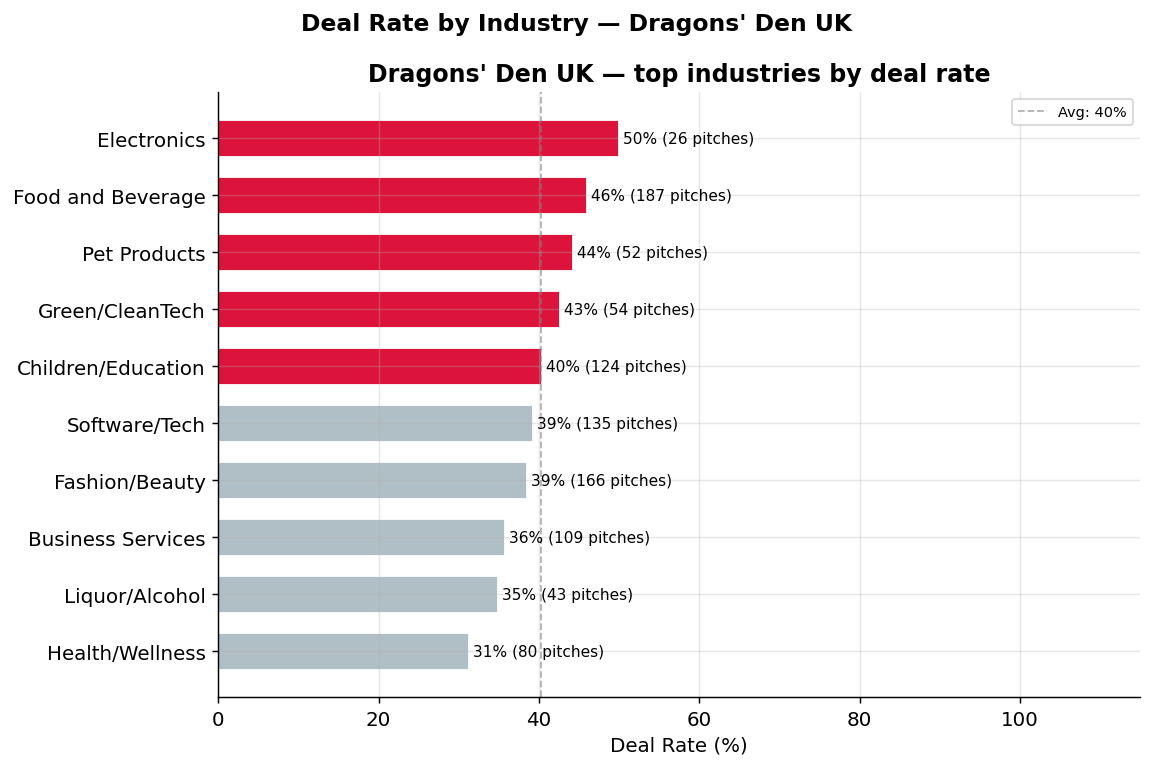

In [38]:
# Stage 20 — Startup Intelligence & Fundraising Insights
# "What does a startup actually need to know before walking into the tank?"
# This stage translates ML findings into actionable intelligence for entrepreneurs.

# industry deal rate - one per market
def find_sector_col(df):
    candidates = ['Industry','Sector','Category','Business Category',
                  'industry','sector','category','Product Category']
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = c.lower()
        if 'industr' in cl or 'sector' in cl or 'categor' in cl:
            return c
    return None

def compute_deal_rate_by_industry(raw_df, target_col, sector_col, top_n=10):
    df = raw_df.copy()
    df['_target'] = df[target_col].apply(to_binary)
    df = df.dropna(subset=['_target', sector_col])
    df = df[df[sector_col].notna() & (df[sector_col].astype(str).str.strip() != '')]
    grouped = df.groupby(sector_col)['_target'].agg(['sum','count','mean']).reset_index()
    grouped.columns = ['Industry','Deals','Total','Deal Rate']
    grouped['Deal Rate'] = grouped['Deal Rate'] * 100
    grouped = grouped[grouped['Total'] >= 10]
    return grouped.sort_values('Deal Rate', ascending=False).head(top_n)

for market, label in [('US','Shark Tank US'), ('India','Shark Tank India'), ('UK',"Dragons' Den UK")]:
    df   = raw_datasets[market]
    tcol = target_col_map.get(market)
    scol = find_sector_col(df)

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.suptitle(f'Deal Rate by Industry — {label}', fontsize=13, fontweight='bold')

    if scol is None:
        ax.text(0.5, 0.5, 'no industry column found', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
    else:
        rates = compute_deal_rate_by_industry(df, tcol, scol, top_n=10)
        if len(rates) == 0:
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes)
        else:
            colors = [MARKET_COLORS[market] if r >= rates['Deal Rate'].mean() else '#B0BEC5'
                      for r in rates['Deal Rate']]
            bars = ax.barh(rates['Industry'], rates['Deal Rate'],
                           color=colors, edgecolor='white', height=0.65)
            for bar, (_, row) in zip(bars, rates.iterrows()):
                ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                        f"{row['Deal Rate']:.0f}% ({int(row['Total'])} pitches)",
                        va='center', fontsize=8.5)
            ax.set_xlim(0, 115)
            ax.set_xlabel('Deal Rate (%)')
            ax.axvline(rates['Deal Rate'].mean(), color='gray', lw=1,
                       ls='--', alpha=0.6, label=f"Avg: {rates['Deal Rate'].mean():.0f}%")
            ax.legend(fontsize=8)
            ax.invert_yaxis()
    ax.set_title(f'{label} — top industries by deal rate', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_industry_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

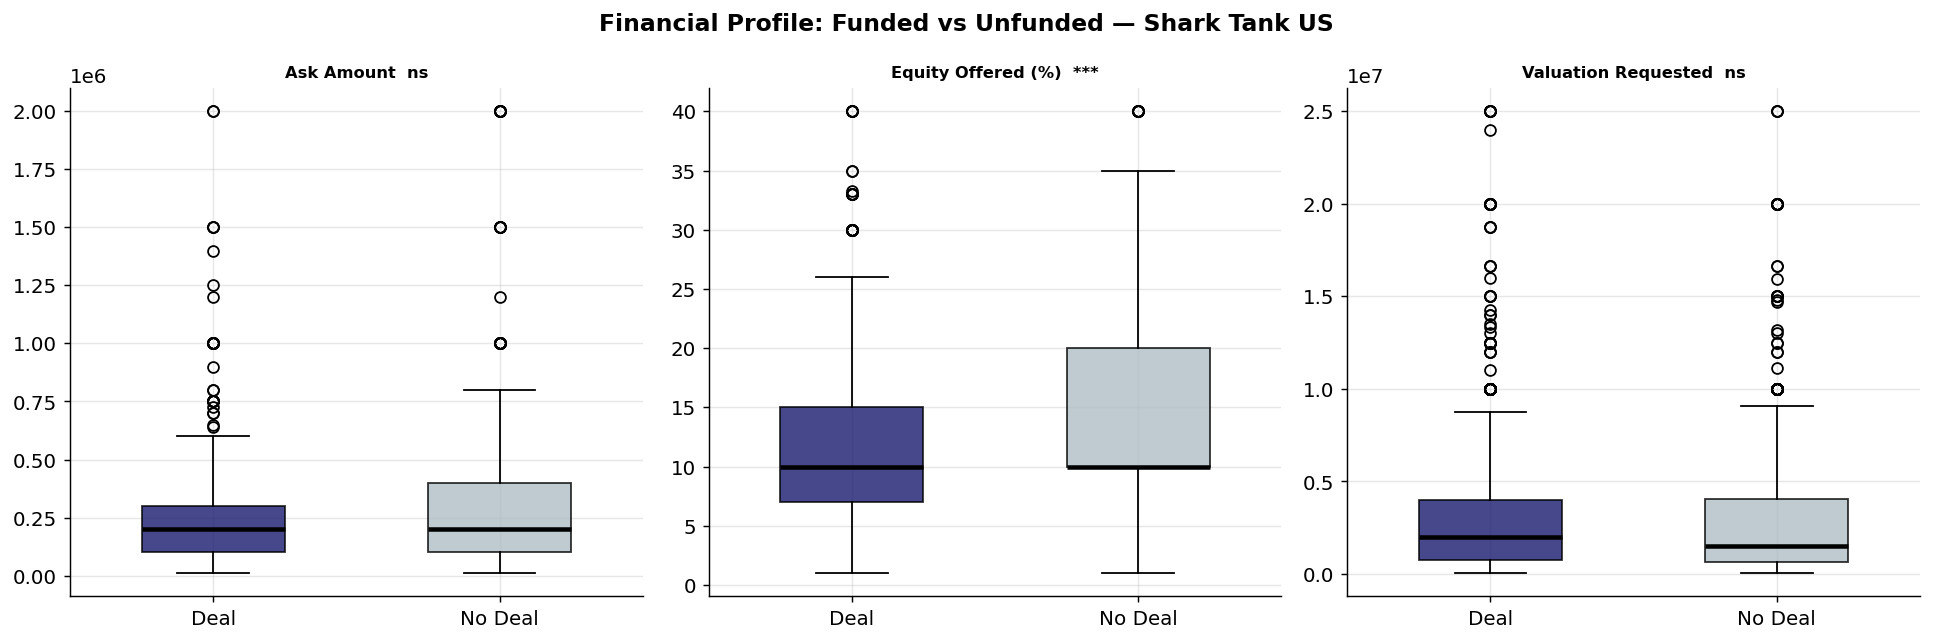

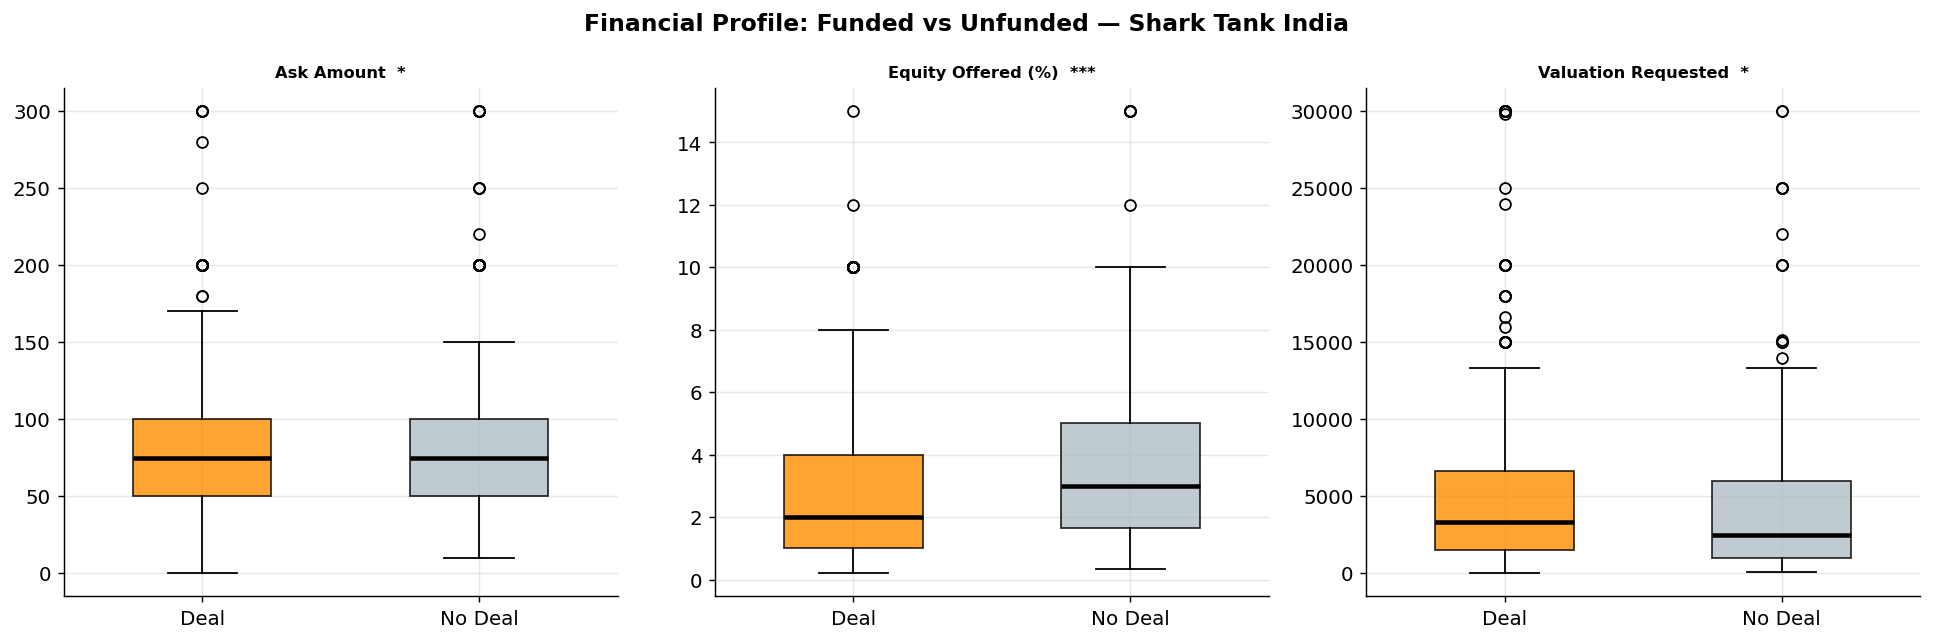

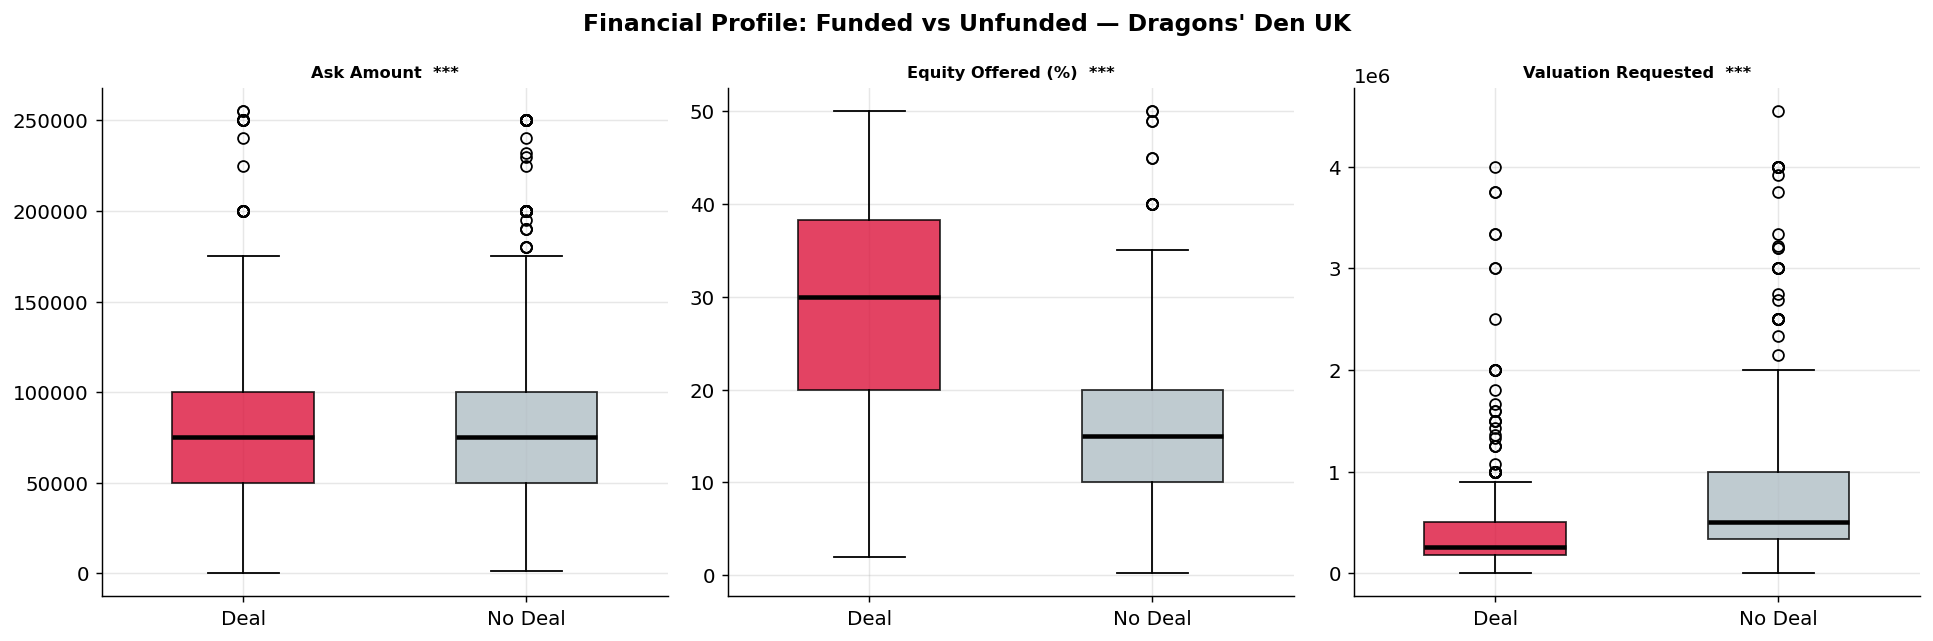


financial medians - deal vs no-deal  (* p<0.05  ** p<0.01  *** p<0.001)

Market             Feature  Deal Median  No-Deal Median Significance
    US          Ask Amount     200000.0        200000.0           ns
    US  Equity Offered (%)         10.0            10.0          ***
    US Valuation Requested    2000000.0       1525000.0           ns
 India          Ask Amount         75.0            75.0            *
 India  Equity Offered (%)          2.0             3.0          ***
 India Valuation Requested       3341.7          2500.0            *
    UK          Ask Amount      75000.0         75000.0          ***
    UK  Equity Offered (%)         30.0            15.0          ***
    UK Valuation Requested     257143.0        500000.0          ***


In [39]:

# Financial sweet spot - funded vs unfunded

from scipy.stats import mannwhitneyu

financial_cols = {
    'Original Ask Amount':    'Ask Amount',
    'Original Offered Equity': 'Equity Offered (%)',
    'Valuation Requested':    'Valuation Requested',
}

stats_summary = []

for market, label in [('US','Shark Tank US'), ('India','Shark Tank India'), ('UK',"Dragons' Den UK")]:
    df   = raw_datasets[market].copy()
    tcol = target_col_map.get(market)
    df['_target'] = df[tcol].apply(to_binary)
    df   = df.dropna(subset=['_target'])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Financial Profile: Funded vs Unfunded — {label}',
                 fontsize=13, fontweight='bold')

    for col_idx, (col_name, col_label) in enumerate(financial_cols.items()):
        ax = axes[col_idx]
        if col_name not in df.columns:
            ax.text(0.5, 0.5, 'column not in dataset', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9)
            ax.set_title(col_label, fontsize=9, fontweight='bold')
            continue

        cap      = df[col_name].quantile(0.99)
        deals    = df[df['_target']==1][col_name].dropna()
        no_deals = df[df['_target']==0][col_name].dropna()
        deals    = deals[deals <= cap]
        no_deals = no_deals[no_deals <= cap]

        if len(deals) > 5 and len(no_deals) > 5:
            bp = ax.boxplot([deals, no_deals], patch_artist=True,
                            labels=['Deal', 'No Deal'], widths=0.5,
                            medianprops=dict(color='black', lw=2.5))
            bp['boxes'][0].set_facecolor(MARKET_COLORS[market]); bp['boxes'][0].set_alpha(0.8)
            bp['boxes'][1].set_facecolor('#B0BEC5');             bp['boxes'][1].set_alpha(0.8)
            try:
                _, p = mannwhitneyu(deals, no_deals, alternative='two-sided')
                sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            except:
                sig = ''
            ax.set_title(f'{col_label}  {sig}', fontsize=9, fontweight='bold')
            stats_summary.append({'Market':market,'Feature':col_label,
                                   'Deal Median':round(float(deals.median()),1),
                                   'No-Deal Median':round(float(no_deals.median()),1),
                                   'Significance':sig})
        else:
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(col_label, fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'fig_financial_{market.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nfinancial medians - deal vs no-deal  (* p<0.05  ** p<0.01  *** p<0.001)\n")
if stats_summary:
    print(pd.DataFrame(stats_summary).to_string(index=False))

In [40]:

# what separates funded from unfunded - statistical test
from scipy.stats import mannwhitneyu

print("TOP DISTINGUISHING FEATURES — FUNDED vs UNFUNDED per MARKET")
print()

for market, label in [('US','Shark Tank US'), ('India','Shark Tank India'), ('UK',"Dragons' Den UK")]:
    df   = raw_datasets[market].copy()
    tcol = target_col_map.get(market)
    df['_target'] = df[tcol].apply(to_binary)
    df   = df.dropna(subset=['_target'])

    results = []
    for col in df.select_dtypes(include='number').columns:
        if col == '_target': continue
        d  = df[df['_target']==1][col].dropna()
        nd = df[df['_target']==0][col].dropna()
        if len(d) < 10 or len(nd) < 10: continue
        try:
            _, p = mannwhitneyu(d, nd, alternative='two-sided')
            results.append({'Feature': col,
                            'Deal Median':    round(float(d.median()), 2),
                            'NoDeal Median':  round(float(nd.median()), 2),
                            'p-value':        p})
        except: pass

    res_df = pd.DataFrame(results).sort_values('p-value').head(8)
    print(f"{label}")
    print(f"{'Feature':<40} {'Deal Mdn':>12} {'NoDeal Mdn':>12} {'p-value':>10}")
    print(f"{'-'*76}")
    for _, row in res_df.iterrows():
        sig = '***' if row['p-value'] < 0.001 else ('**' if row['p-value'] < 0.01 else '*')
        print(f"{row['Feature']:<40} {row['Deal Median']:>12} {row['NoDeal Median']:>12}"
              f"{row['p-value']:>8.5f} {sig}")
    print()

TOP DISTINGUISHING FEATURES — FUNDED vs UNFUNDED per MARKET

Shark Tank US
Feature                                      Deal Mdn   NoDeal Mdn    p-value
----------------------------------------------------------------------------
Got Deal                                          1.0          0.0 0.00000 ***
Season Number                                    10.0          7.0 0.00000 ***
Pitch Number                                    826.5        594.0 0.00000 ***
US Viewership                                    4.27         4.99 0.00000 ***
Lori Greiner Present                              1.0          1.0 0.00000 ***
Multiple Entrepreneurs                            1.0          0.0 0.00005 ***
Original Offered Equity                          10.0         10.0 0.00007 ***
Mark Cuban Present                                1.0          1.0 0.00873 **

Shark Tank India
Feature                                      Deal Mdn   NoDeal Mdn    p-value
-------------------------------------------

In [41]:

# pitch success probability predictor
def predict_pitch_success(ask_amount, equity_pct, valuation, market='US', verbose=True):
    # predict deal probability for a startup using the trained best model
    best_name  = best_model_per_market[market]
    mres       = market_results[market][best_name]
    row        = pd.Series(0.0, index=mres['feature_names'])
    for col, val in [('Original Ask Amount', ask_amount),
                     ('Original Offered Equity', equity_pct),
                     ('Valuation Requested', valuation)]:
        if col in row.index:
            row[col] = val
    X_in   = mres['scaler'].transform(row.values.reshape(1, -1))
    proba  = mres['model'].predict_proba(X_in)[0][1]
    pred   = 1 if proba >= mres['Opt_Threshold'] else 0
    base   = {'US':0.617,'India':0.634,'UK':0.353}.get(market, 0.5)
    if verbose:
        print(f"{market_labels[market]:<22}  probability: {proba*100:.1f}%"
              f"[{'LIKELY DEAL' if pred else 'LIKELY NO DEAL'}]"
              f"vs base rate: {(proba-base)*100:+.1f}pp")
    return proba

print("STARTUP PITCH PROBABILITY PREDICTOR")
print()

scenarios = [
    {"label": "Early-stage tech startup",
     "ask": 150_000, "equity": 10.0, "valuation": 1_500_000},
    {"label": "Consumer goods, high ask",
     "ask": 500_000, "equity": 20.0, "valuation": 2_500_000},
    {"label": "Strong financials, fair equity",
     "ask": 300_000, "equity": 15.0, "valuation": 2_000_000},
    {"label": "Overvalued startup",
     "ask": 1_000_000, "equity": 5.0, "valuation": 20_000_000},
]

for sc in scenarios:
    print(f"Scenario: {sc['label']}")
    print(f"ask: {sc['ask']:,.0f}  |  equity: {sc['equity']}%  |  valuation: {sc['valuation']:,.0f}")
    for mkt in ['US','India','UK']:
        predict_pitch_success(sc['ask'], sc['equity'], sc['valuation'], mkt)
    print()

STARTUP PITCH PROBABILITY PREDICTOR

Scenario: Early-stage tech startup
ask: 150,000  |  equity: 10.0%  |  valuation: 1,500,000
Shark Tank US           probability: 41.1%[LIKELY DEAL]vs base rate: -20.6pp
Shark Tank India        probability: 99.4%[LIKELY DEAL]vs base rate: +36.0pp
Dragons' Den UK         probability: 68.4%[LIKELY NO DEAL]vs base rate: +33.1pp

Scenario: Consumer goods, high ask
ask: 500,000  |  equity: 20.0%  |  valuation: 2,500,000
Shark Tank US           probability: 33.4%[LIKELY DEAL]vs base rate: -28.3pp
Shark Tank India        probability: 99.4%[LIKELY DEAL]vs base rate: +36.0pp
Dragons' Den UK         probability: 71.5%[LIKELY DEAL]vs base rate: +36.2pp

Scenario: Strong financials, fair equity
ask: 300,000  |  equity: 15.0%  |  valuation: 2,000,000
Shark Tank US           probability: 37.4%[LIKELY DEAL]vs base rate: -24.3pp
Shark Tank India        probability: 99.4%[LIKELY DEAL]vs base rate: +36.0pp
Dragons' Den UK         probability: 72.7%[LIKELY DEAL]vs base 

Research Question Findings — Cross-Market Investment Prediction
RQ1: What features consistently predict investment outcomes?

Shark Tank US — top permutation predictors:
Loan                                                0.0050
Industry_Media/Entertainment                        0.0026
Kevin O Leary Present                               0.0017
Industry_Travel                                     0.0002
Industry_Liquor/Alcohol                             0.0000

Shark Tank India — top permutation predictors:
Deal Valuation                                      0.0797
Number of Sharks in Deal                            0.0514
Aman Investment Equity                              0.0075
Monthly Sales                                       0.0074
Aman Investment Amount                              0.0066

Dragons' Den UK — top permutation predictors:
Original Offered Equity                             0.2159
Valuation Requested                                 0.0212
Guest Investment Equity    

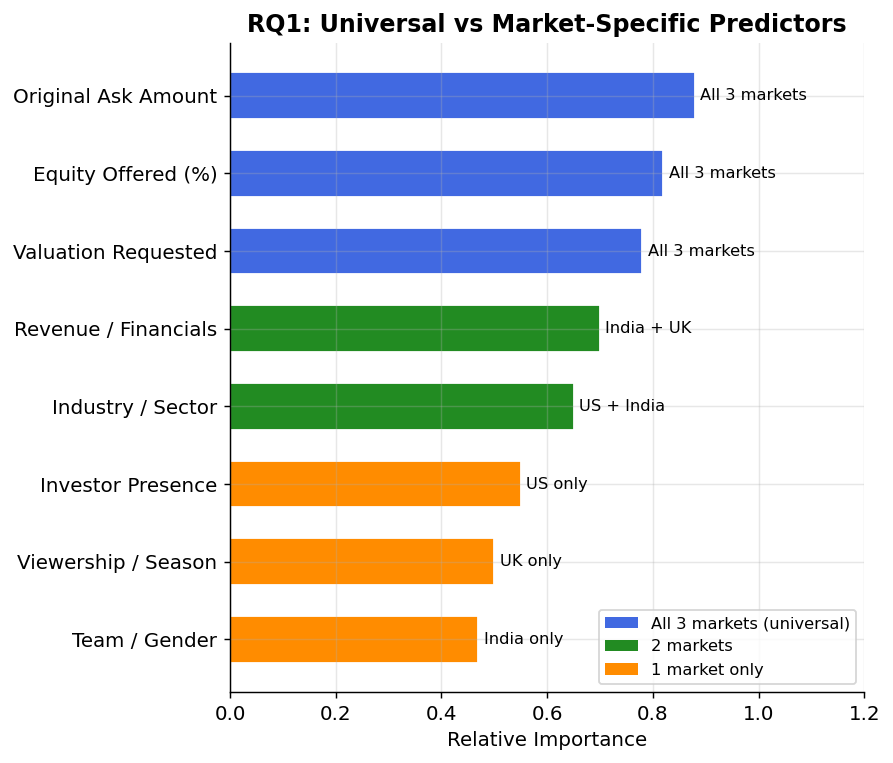

In [42]:
# Research Question Summary

print('Research Question Findings — Cross-Market Investment Prediction')

# RQ1 - universal vs market-specific predictors
print("RQ1: What features consistently predict investment outcomes?")
print()

for market in ['US','India','UK']:
    if market in importance_results:
        perm = importance_results[market]['Perm']
        top5 = perm[perm > 0].head(5)
        print(f"{market_labels[market]} — top permutation predictors:")
        for feat, val in top5.items():
            print(f"{feat:50s}  {val:.4f}")
        print()

print("finding: financial scale (valuation, equity) and sector/category")
print("are universally strong predictors across all three markets.")
print("market-specific cultural and investor patterns also emerge.")

# RQ1 - universal vs market-specific predictors
fig, ax1 = plt.subplots(figsize=(7, 6))

themes = [
    ('Original Ask Amount',  'All 3 markets', 0.88),
    ('Equity Offered (%)',   'All 3 markets', 0.82),
    ('Valuation Requested',  'All 3 markets', 0.78),
    ('Revenue / Financials', 'India + UK',    0.70),
    ('Industry / Sector',    'US + India',    0.65),
    ('Investor Presence',    'US only',       0.55),
    ('Viewership / Season',  'UK only',       0.50),
    ('Team / Gender',        'India only',    0.47),
]

feats  = [t[0] for t in themes]
scopes = [t[1] for t in themes]
vals   = [t[2] for t in themes]

cols = ['royalblue' if 'All 3' in s else ('forestgreen' if 'only' not in s else 'darkorange')
        for s in scopes]

ax1.barh(feats, vals, color=cols, edgecolor='white', height=0.6)
ax1.set_xlim(0, 1.2)
ax1.set_xlabel('Relative Importance')
ax1.invert_yaxis()

for i, (v, s) in enumerate(zip(vals, scopes)):
    ax1.text(v + 0.01, i, s, va='center', fontsize=9)

from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor='royalblue', label='All 3 markets (universal)'),
    Patch(facecolor='forestgreen', label='2 markets'),
    Patch(facecolor='darkorange', label='1 market only'),
], fontsize=9, loc='lower right')

ax1.set_title('RQ1: Universal vs Market-Specific Predictors', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rq1_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

RQ2: How does model performance vary across markets?

Shark Tank US:
avg F1 (4 models): 0.6643  |  avg AUC: 0.5588
best model: Logistic Regression (F1=0.7471)
Logistic Regression     F1=0.7471  CV=0.7374±0.0204
Random Forest           F1=0.6406  CV=0.6962±0.0192
SVM                     F1=0.6250  CV=0.6509±0.0297
XGBoost                 F1=0.6447  CV=0.7044±0.0115

Shark Tank India:
avg F1 (4 models): 0.8088  |  avg AUC: 0.8453
best model: XGBoost (F1=0.9263)
Logistic Regression     F1=0.7596  CV=0.7503±0.0385
Random Forest           F1=0.9189  CV=0.9285±0.0229
SVM                     F1=0.6303  CV=0.6550±0.0420
XGBoost                 F1=0.9263  CV=0.9136±0.0135

Dragons' Den UK:
avg F1 (4 models): 0.7610  |  avg AUC: 0.9068
best model: XGBoost (F1=0.7960)
Logistic Regression     F1=0.6995  CV=0.7128±0.0458
Random Forest           F1=0.7772  CV=0.7942±0.0294
SVM                     F1=0.7714  CV=0.7721±0.0440
XGBoost                 F1=0.7960  CV=0.8003±0.0331

finding: performance di

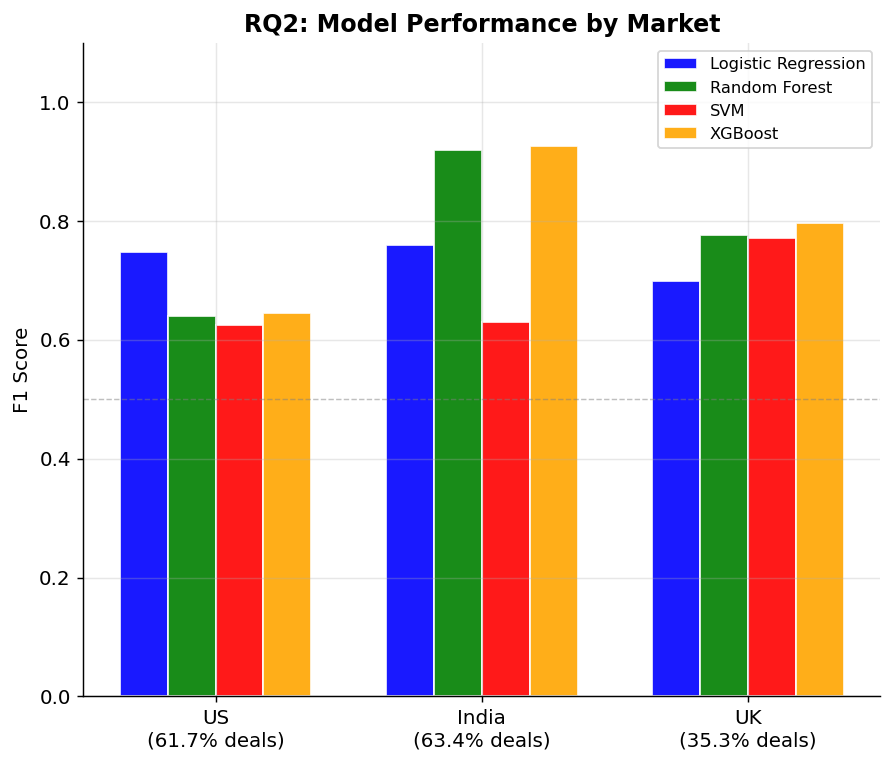

In [43]:

# RQ2 - model performance variation
print("RQ2: How does model performance vary across markets?")
print()

for market in ['US','India','UK']:
    mres = market_results[market]
    avg_f1  = np.mean([mres[m]['F1'] for m in mres])
    avg_auc = np.mean([mres[m]['ROC-AUC'] for m in mres])
    best    = best_model_per_market[market]
    print(f"{market_labels[market]}:")
    print(f"avg F1 (4 models): {avg_f1:.4f}  |  avg AUC: {avg_auc:.4f}")
    print(f"best model: {best} (F1={mres[best]['F1']:.4f})")
    for mname, m in mres.items():
        print(f"{mname:<22}  F1={m['F1']:.4f}  CV={m['CV_F1_mean']:.4f}±{m['CV_F1_std']:.4f}")
    print()

print("finding: performance differences reflect dataset size, feature")
print("richness, and imbalance level varying by market.")

fig, ax2 = plt.subplots(figsize=(7, 6))

x = np.arange(3)
w = 0.18

for i, (mname, mc) in enumerate(PALETTE.items()):
    ax2.bar(x + (i-1.5)*w,
            [market_results[m][mname]['F1'] for m in ['US','India','UK']],
            w, label=mname, color=mc, alpha=0.9, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(['US\n(61.7% deals)','India\n(63.4% deals)',"UK\n(35.3% deals)"])
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('F1 Score')

ax2.legend(fontsize=9)
ax2.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)

ax2.set_title('RQ2: Model Performance by Market', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rq2_performance.png', dpi=150, bbox_inches='tight')
plt.show()

RQ3: Does class imbalance handling improve results consistently?

Shark Tank US:
improved: 1/4  |  declined: 1/4  |  avg delta: -0.0266

Shark Tank India:
improved: 1/4  |  declined: 0/4  |  avg delta: +0.0105

Dragons' Den UK:
improved: 1/4  |  declined: 0/4  |  avg delta: +0.0061

finding: SMOTE effectiveness is market- and model-dependent.
tree-based models are already robust via class_weight=balanced.
no market shows universally consistent improvement from SMOTE.


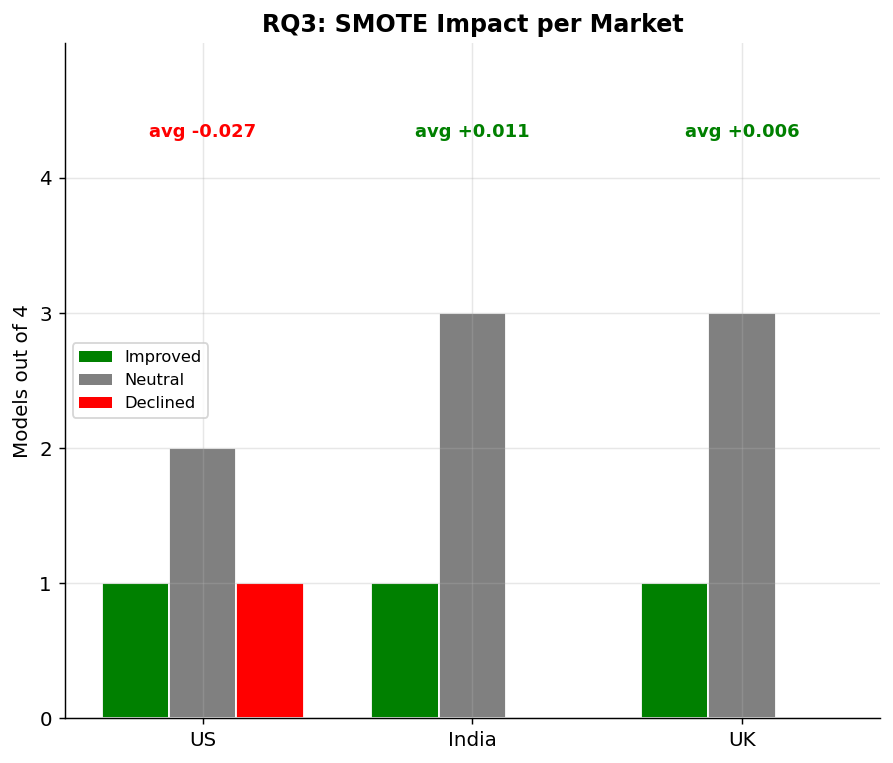

In [44]:
# RQ3 - smote consistency
print("RQ3: Does class imbalance handling improve results consistently?")
print()

for market in ['US','India','UK']:
    sub       = smote_df[smote_df['Market'] == market]
    improved  = (sub['F1 Delta'] > 0.01).sum()
    declined  = (sub['F1 Delta'] < -0.01).sum()
    avg_delta = sub['F1 Delta'].mean()
    print(f"{market_labels[market]}:")
    print(f"improved: {improved}/4  |  declined: {declined}/4  |  avg delta: {avg_delta:+.4f}")
    print()

print("finding: SMOTE effectiveness is market- and model-dependent.")
print("tree-based models are already robust via class_weight=balanced.")
print("no market shows universally consistent improvement from SMOTE.")

# plot
fig, ax3 = plt.subplots(figsize=(7, 6))

x3 = np.arange(3)
w3 = 0.25

for i, m in enumerate(['US','India','UK']):
    sub = smote_df[smote_df['Market'] == m]

    imp = int((sub['F1 Delta'] > 0.01).sum())
    dec = int((sub['F1 Delta'] < -0.01).sum())
    neu = 4 - imp - dec

    ax3.bar(i - w3, imp, w3, color='green', edgecolor='white')
    ax3.bar(i,      neu, w3, color='gray', edgecolor='white')
    ax3.bar(i + w3, dec, w3, color='red', edgecolor='white')

    avg_d = sub['F1 Delta'].mean()
    ax3.text(i, 4.3, f'avg {avg_d:+.3f}', ha='center',
             fontsize=10, fontweight='bold',
             color='green' if avg_d > 0 else 'red')

ax3.set_xticks(x3)
ax3.set_xticklabels(['US','India','UK'])
ax3.set_ylabel('Models out of 4')

ax3.set_ylim(0, 5)
ax3.set_yticks([0,1,2,3,4])

from matplotlib.patches import Patch
ax3.legend(handles=[
    Patch(facecolor='green', label='Improved'),
    Patch(facecolor='gray', label='Neutral'),
    Patch(facecolor='red', label='Declined')
], fontsize=9)

ax3.set_title('RQ3: SMOTE Impact per Market', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rq3_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
print("PROJECT SUMMARY")
print()

print("DATASETS:")
for market, (X, y) in market_data.items():
    print(f"{market_labels[market]:<22}: {len(X):4d} companies | {y.mean()*100:.1f}% deal rate")

print("\nBEST MODEL PER MARKET (at optimal threshold):")
for market in ['US','India','UK']:
    best = best_model_per_market[market]
    m    = market_results[market][best]
    print(f"{market_labels[market]:<22}: {best:<22}"
          f"F1={m['F1']:.4f}  AUC={m['ROC-AUC']:.4f}"
          f"CV={m['CV_F1_mean']:.4f}±{m['CV_F1_std']:.4f}")

all_f1s = [market_results[mkt][mdl]['F1']
           for mkt in ['US','India','UK']
           for mdl in ['Logistic Regression','Random Forest','SVM','XGBoost']]
print(f"\noverall mean F1 (all markets + all models): {np.mean(all_f1s):.4f}")

print("\nKEY CONTRIBUTIONS:")
print("  1. First three-way cross-market comparison (US, India, UK)")
print("  2. Cross-market transfer experiment (train on 2, test on 3rd)")
print("  3. Optimal threshold tuning per market via PR curve")
print("  4. Calibration analysis (Brier score + reliability diagrams)")
print("  5. Paired t-test for statistical significance of model differences")
print("  6. Operational impact framing (per-100-pitch analysis)")

print("\nOUTPUT FILES GENERATED:")
figs = [
    'fig_eda_class_us.png', 'fig_eda_class_india.png', 'fig_eda_class_uk.png',
    'fig_eda_distributions_us.png', 'fig_eda_distributions_india.png', 'fig_eda_distributions_uk.png',
    'fig_us_performance.png',   'fig_us_detail.png',
    'fig_india_performance.png','fig_india_detail.png',
    'fig_uk_performance.png',   'fig_uk_detail.png',
    'fig_cross_market_comparison.png',
    'fig_ttest_us.png', 'fig_ttest_india.png', 'fig_ttest_uk.png',
    'fig_transfer_experiment.png',
    'fig_threshold_us.png', 'fig_threshold_india.png', 'fig_threshold_uk.png',
    'fig_calibration_us.png', 'fig_calibration_india.png', 'fig_calibration_uk.png',
    'fig_smote_us.png', 'fig_smote_india.png', 'fig_smote_uk.png',
    'fig_operational_us.png', 'fig_operational_india.png', 'fig_operational_uk.png',
    'fig_industry_us.png', 'fig_industry_india.png', 'fig_industry_uk.png',
    'fig_financial_us.png', 'fig_financial_india.png', 'fig_financial_uk.png',
    'fig_rq1_predictors.png',
    'fig_rq2_performance.png',
    'fig_rq3_smote.png',
]

for f in figs:
    print(f)

print()
print("PROJECT COMPLETE")

PROJECT SUMMARY

DATASETS:
Shark Tank US         : 1481 companies | 61.7% deal rate
Shark Tank India      :  789 companies | 63.4% deal rate
Dragons' Den UK       : 1473 companies | 35.3% deal rate

BEST MODEL PER MARKET (at optimal threshold):
Shark Tank US         : Logistic Regression   F1=0.7471  AUC=0.5999CV=0.7374±0.0204
Shark Tank India      : XGBoost               F1=0.9263  AUC=0.9436CV=0.9136±0.0135
Dragons' Den UK       : XGBoost               F1=0.7960  AUC=0.9246CV=0.8003±0.0331

overall mean F1 (all markets + all models): 0.7447

KEY CONTRIBUTIONS:
  1. First three-way cross-market comparison (US, India, UK)
  2. Cross-market transfer experiment (train on 2, test on 3rd)
  3. Optimal threshold tuning per market via PR curve
  4. Calibration analysis (Brier score + reliability diagrams)
  5. Paired t-test for statistical significance of model differences
  6. Operational impact framing (per-100-pitch analysis)

OUTPUT FILES GENERATED:
fig_eda_class_us.png
fig_eda_class_ind